<a href="https://colab.research.google.com/github/RifatulHidayah/ml-prediction-early-marriage-jateng/blob/main/Prediksi_Pernikahan_Dini_Jateng_RF_dan_SVM_Data_Susenas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install dependency

In [1]:
!pip install -q imbalanced-learn statsmodels pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.4 MB/s eta 0:00:00


Install library

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, classification_report, matthews_corrcoef, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline

from statsmodels.stats.contingency_tables import mcnemar

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

Upload file

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/TA/data dipakai.csv", delimiter=";", na_values=["NULL", "#NULL!"])

df.shape
df.head()

,urut,r101,r102,r105,r404,r405,r407,r409,r614,r707,fwt
0,4149,33,1,2,2,1,39,32.0,13.0,5.0,"269,04543820010200"
1,4701,33,1,1,2,2,28,17.0,3.0,NaN,"88,36478077784630"
2,5334,33,1,1,2,1,51,22.0,3.0,5.0,"1027,77477969981000"
3,10184,33,1,2,2,2,40,19.0,8.0,1.0,"71,59625714913750"
4,10615,33,1,2,2,2,30,22.0,8.0,NaN,"265,82010956063300"


In [5]:
#ubah nama kolom
df = df.rename(columns={
    'r102': 'kab_kota',
    'r105': 'tipe_daerah',
    'r404': 'status_kawin',
    'r405': 'jenis_kelamin',
    'r407': 'usia',
    'r409': 'usia_kawin_pertama',
    'r614': 'pendidikan',
    'r707': 'pekerjaan'
})
df.head()

,urut,r101,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,usia_kawin_pertama,pendidikan,pekerjaan,fwt
0,4149,33,1,2,2,1,39,32.0,13.0,5.0,"269,04543820010200"
1,4701,33,1,1,2,2,28,17.0,3.0,NaN,"88,36478077784630"
2,5334,33,1,1,2,1,51,22.0,3.0,5.0,"1027,77477969981000"
3,10184,33,1,2,2,2,40,19.0,8.0,1.0,"71,59625714913750"
4,10615,33,1,2,2,2,30,22.0,8.0,NaN,"265,82010956063300"


KONSTRUKSI LABEL TARGET


In [6]:
df['pernikahan_dini'] = (df['usia_kawin_pertama'] < 19).astype(int)

Jumlah data tiap kelas:
pernikahan_dini
0    85906
1    13541
Name: count, dtype: int64

Persentase tiap kelas:
pernikahan_dini
0    86.383702
1    13.616298
Name: proportion, dtype: float64
Total data: 99447


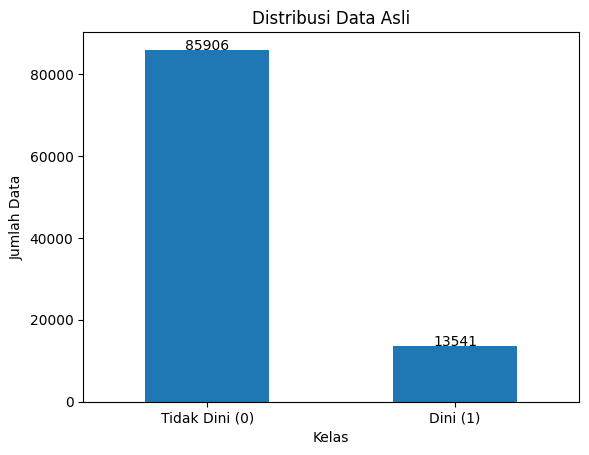

In [7]:
import matplotlib.pyplot as plt

# hitung jumlah kelas
counts = df['pernikahan_dini'].value_counts().sort_index() #mengurutkan berdasarkan index 0->1

# hitung persentase
persen = df['pernikahan_dini'].value_counts(normalize=True).sort_index() * 100 #hasil dalam bentuk persentase

# print jumlah data
print("Jumlah data tiap kelas:")
print(counts)

print("\nPersentase tiap kelas:")
print(persen)

print("Total data:", len(df)) #menghitung jumlah baris

# buat grafik bar/batang
ax = counts.plot(kind='bar')

# tampilkan angka di atas bar
for i, v in enumerate(counts):#i posisi batang, v jumlah data
    ax.text(i, v + 100, str(v), ha='center') #v + 100 vertikal diatas batang, str = string (teks)

plt.title('Distribusi Data Asli')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.xticks([0,1], ['Tidak Dini (0)', 'Dini (1)'], rotation=0)

plt.show()

Cleaning

In [8]:
#drop kolom yang tidak dipakai
df = df.drop(columns=['urut', 'r101', 'fwt'], errors='ignore')

df.head()

,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,usia_kawin_pertama,pendidikan,pekerjaan,pernikahan_dini
0,1,2,2,1,39,32.0,13.0,5.0,0
1,1,1,2,2,28,17.0,3.0,NaN,1
2,1,1,2,1,51,22.0,3.0,5.0,0
3,1,2,2,2,40,19.0,8.0,1.0,0
4,1,2,2,2,30,22.0,8.0,NaN,0


INFO DATASET

In [9]:
# Info dataset
df.info()

# Hitung missing values tiap kolom
print("Jumlah missing values tiap kolom:")
print(df.isna().sum())

#cek duplikat
duplikat_count = df.duplicated().sum()
print("Jumlah data duplikat:", duplikat_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99447 entries, 0 to 99446
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kab_kota            99447 non-null  int64  
 1   tipe_daerah         99447 non-null  int64  
 2   status_kawin        99447 non-null  int64  
 3   jenis_kelamin       99447 non-null  int64  
 4   usia                99447 non-null  int64  
 5   usia_kawin_pertama  61635 non-null  float64
 6   pendidikan          88046 non-null  float64
 7   pekerjaan           53064 non-null  float64
 8   pernikahan_dini     99447 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.8 MB
Jumlah missing values tiap kolom:
kab_kota                  0
tipe_daerah               0
status_kawin              0
jenis_kelamin             0
usia                      0
usia_kawin_pertama    37812
pendidikan            11401
pekerjaan             46383
pernikahan_dini           0
dtype: int64
Juml

DATA DUPLIKAT

In [10]:
# Hapus baris duplikat
df = df.drop_duplicates()

# Cek ukuran data setelah hapus
print("Ukuran data setelah hapus duplikat:", df.shape)

# Cek ulang missing values
print("\nMissing values setelah hapus duplikat:")
print(df.isna().sum())


Ukuran data setelah hapus duplikat: (71911, 9)

Missing values setelah hapus duplikat:
kab_kota                  0
tipe_daerah               0
status_kawin              0
jenis_kelamin             0
usia                      0
usia_kawin_pertama    11827
pendidikan             3407
pekerjaan             21565
pernikahan_dini           0
dtype: int64


In [11]:
# Hapus baris yang missing di kolom usia_kawin_pertama saja, karena usia kawin krusial dan harus ada
df= df.dropna(subset=['usia_kawin_pertama'])

# Cek ukuran data setelah dihapus
df.shape

# Cek missing values lagi
df.isnull().sum()


,0
kab_kota,0
tipe_daerah,0
status_kawin,0
jenis_kelamin,0
usia,0
usia_kawin_pertama,0
pendidikan,2289
pekerjaan,15676
pernikahan_dini,0


In [12]:
##filter status kawin karena 1 == belum menikah, 2 == menikah, 3 == cerai hidup, 4 == cerai mati
print("Sebelum filter status kawin:", df.shape)

df= df[df['status_kawin'].isin([2, 3, 4])] #saring data berdasarkan kolom, 1 dihapus karena tidak termasuk pernikahan dini

print("Sesudah filter status kawin:", df.shape)

Sebelum filter status kawin: (60084, 9)
Sesudah filter status kawin: (60084, 9)


In [13]:
df.isnull().sum()

,0
kab_kota,0
tipe_daerah,0
status_kawin,0
jenis_kelamin,0
usia,0
usia_kawin_pertama,0
pendidikan,2289
pekerjaan,15676
pernikahan_dini,0


IMPUTASI MISSING VALUES

In [14]:
##menggunakan modus karena data kategorikal
#modus pendidikan untuk imputasi
print("Frekuensi pendidikan:")
print(df['pendidikan'].value_counts().head()) #menghitung jumlah fitur yang muncul di setiap kategori
print("Modus pendidikan:", df['pendidikan'].mode()[0])
#modus pekerjaan untuk imputasi
print("Frekuensi pekerjaan:")
print(df['pekerjaan'].value_counts().head())
print("Modus pekerjaan:", df['pekerjaan'].mode()[0])

Frekuensi pendidikan:
pendidikan
3.0     17352
8.0      9343
13.0     8811
25.0     8580
15.0     4285
Name: count, dtype: int64
Modus pendidikan: 3.0
Frekuensi pekerjaan:
pekerjaan
4.0    14961
1.0    11088
2.0     7445
5.0     5225
6.0     4211
Name: count, dtype: int64
Modus pekerjaan: 4.0


3.0 = SD;
8.0 = SMP;
13.0 = SMA;
25.0 = Tidak punya ijazah SD;
15.0 = SMK

4.0 = Buruh/Karyawan/Pegawai;
1.0 = Berusaha Sendiri;
2.0 = Berusaha dibantu/buruh tdk tetap/pekerja keluarga,tidak dibayar;
5.0 = Pekerja Bebas;
6.0 = Pekerja keluarga/tidak dibayar


In [15]:
# Imputasi pendidikan dengan modus
imputer_mode = SimpleImputer(strategy='most_frequent')
df['pendidikan'] = imputer_mode.fit_transform(df[['pendidikan']])

# Imputasi pekerjaan dengan modus
df['pekerjaan'] = imputer_mode.fit_transform(df[['pekerjaan']])

# Cek hasil
print(df.isna().sum())
print(df.shape)
df.head(10)

kab_kota              0
tipe_daerah           0
status_kawin          0
jenis_kelamin         0
usia                  0
usia_kawin_pertama    0
pendidikan            0
pekerjaan             0
pernikahan_dini       0
dtype: int64
(60084, 9)


,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,usia_kawin_pertama,pendidikan,pekerjaan,pernikahan_dini
0,1,2,2,1,39,32.0,13.0,5.0,0
1,1,1,2,2,28,17.0,3.0,4.0,1
2,1,1,2,1,51,22.0,3.0,5.0,0
3,1,2,2,2,40,19.0,8.0,1.0,0
4,1,2,2,2,30,22.0,8.0,4.0,0
5,1,1,2,1,67,33.0,25.0,2.0,0
6,1,2,4,1,73,20.0,3.0,1.0,0
7,1,2,2,1,62,22.0,4.0,1.0,0
8,1,1,4,2,60,25.0,3.0,2.0,0
9,1,2,2,1,60,25.0,25.0,5.0,0


In [16]:
df.isnull().sum()


,0
kab_kota,0
tipe_daerah,0
status_kawin,0
jenis_kelamin,0
usia,0
usia_kawin_pertama,0
pendidikan,0
pekerjaan,0
pernikahan_dini,0


In [17]:
cols = ['usia_kawin_pertama', 'pendidikan', 'pekerjaan'] #ubah tipe data

df[cols] = df[cols].astype(int)

df.head()


,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,usia_kawin_pertama,pendidikan,pekerjaan,pernikahan_dini
0,1,2,2,1,39,32,13,5,0
1,1,1,2,2,28,17,3,4,1
2,1,1,2,1,51,22,3,5,0
3,1,2,2,2,40,19,8,1,0
4,1,2,2,2,30,22,8,4,0


In [18]:
df.dtypes


,0
kab_kota,int64
tipe_daerah,int64
status_kawin,int64
jenis_kelamin,int64
usia,int64
usia_kawin_pertama,int64
pendidikan,int64
pekerjaan,int64
pernikahan_dini,int64


EDA

untuk pendidikan
01. Paket A
02. SDLB
03. SD
04. MI
05. SPM/PDF Ula
06. Paket B
07. SMP LB
08. SMP
09. MTs
10. SPM/PDF Wustha
11. Paket C
12. SMLB
13. SMA
14. MA
15. SMK
16. MAK
17. SPM/PDF Ulya
18. D1/D2
19. D3     
20. D4
21. S1
22. Profesi
23. S2
24. S3
25. Tidak Punya Ijazah SD



untuk pekerjaan


1. Berusaha sendiri
2. Berusaha dibantu buruh tidak tetap/pekerja keluarga/ tidak dibayar  
3. Berusaha dibantu buruh tetap dan dibayar
4. Buruh/karyawan/pegawai
5. Pekerja bebas
6. Pekerja keluarga atau tidak dibayar



untuk jk
1. laki laki
2. perempuan



kab/kota
1. CILACAP
2. BANYUMAS
3. PURBALINGGA
4. BANJARNEGARA
5. KEBUMEN
6. PURWOREJO
7. WONOSOBO
8. MAGELANG
9. BOYOLALI
10. KLATEN
11. SUKOHARJO
12. WONOGIRI
13. KARANGANYAR
14. SRAGEN
15. GROBOGAN
16. BLORA
17. REMBANG
18. PATI
19. KUDUS
20. JEPARA
21. DEMAK
22. SEMARANG
23. TEMANGGUNG
24. KENDAL
25. BATANG
26. PEKALONGAN
27. PEMALANG
28. TEGAL
29. BREBES
71. MAGELANG
72. SURAKARTA
73. SALATIGA
74. SEMARANG
75. PEKALONGAN
76. TEGAL

untuk tipe daerah
1. perkotaan
2. pedesaan

untuk status kawin
1.Belum
kawin  
2.Kawin
3.Cerai
hidup  
4.Cerai
mati



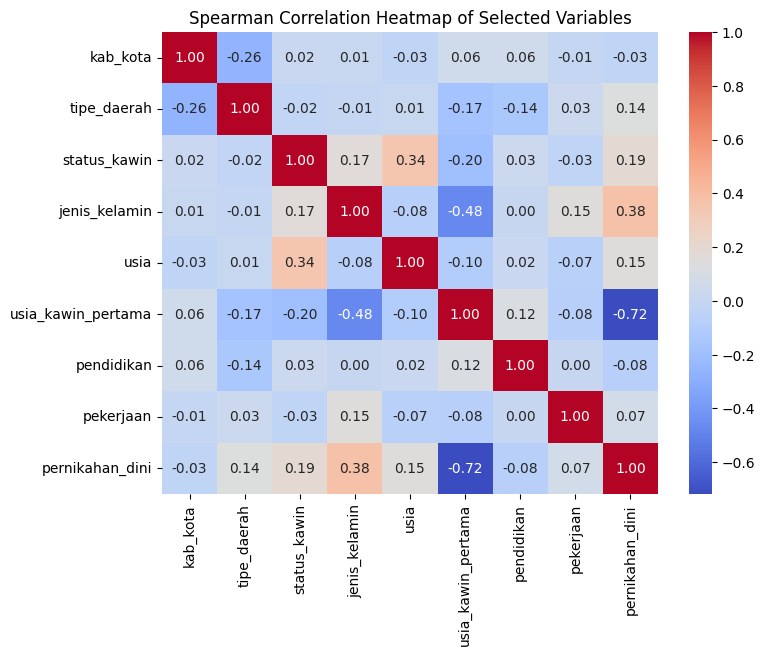

In [19]:
corr_matrix = df.corr(method='spearman') #menghitung korelasi antar variabel numerik

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Spearman Correlation Heatmap of Selected Variables')
plt.show()

#1 = positif kuat, 0 = tidak ada hubungan, -1 = negatif kuat

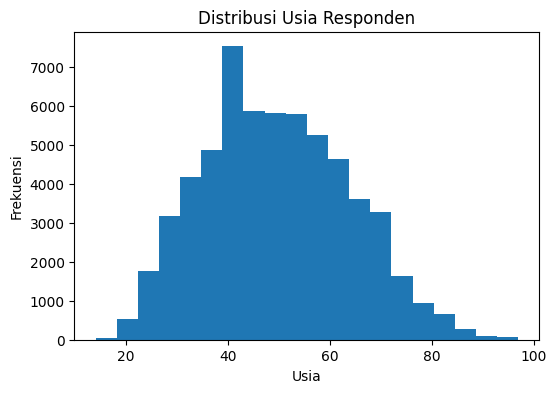

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['usia'], bins=20)
plt.title('Distribusi Usia Responden')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()


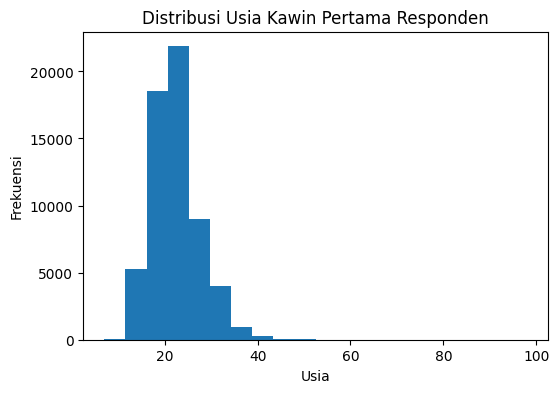

In [21]:
plt.figure(figsize=(6,4))
plt.hist(df['usia_kawin_pertama'], bins=20)
plt.title('Distribusi Usia Kawin Pertama Responden')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()

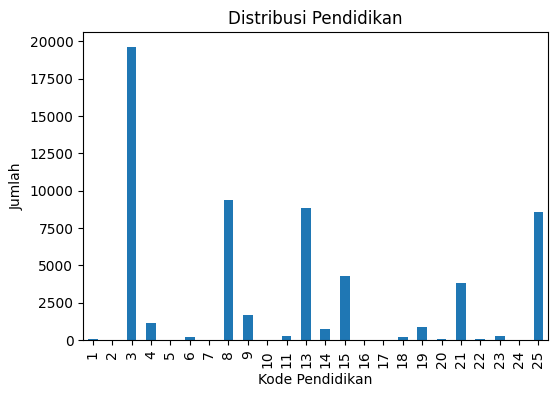

In [22]:
plt.figure(figsize=(6,4))
df['pendidikan'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Pendidikan')
plt.xlabel('Kode Pendidikan')
plt.ylabel('Jumlah')
plt.show()


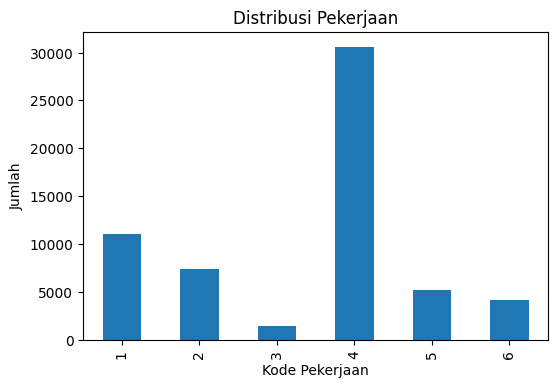

In [23]:
plt.figure(figsize=(6,4))
df['pekerjaan'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Pekerjaan')
plt.xlabel('Kode Pekerjaan')
plt.ylabel('Jumlah')
plt.show()


OUTLIER

In [24]:
#cek outlier
def deteksi_outlier_iqr(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]

    print(f"Kolom: {kolom}")
    print(f"Q1 = {Q1}")
    print(f"Q3 = {Q3}")
    print(f"IQR = {IQR}")
    print(f"Batas bawah = {lower_bound}")
    print(f"Batas atas  = {upper_bound}")
    print(f"Jumlah outlier = {outlier.shape[0]}")
    print("-" * 40)

    return lower_bound, upper_bound, outlier


Kolom: usia
Q1 = 39.0
Q3 = 60.0
IQR = 21.0
Batas bawah = 7.5
Batas atas  = 91.5
Jumlah outlier = 85
----------------------------------------
Kolom: usia_kawin_pertama
Q1 = 19.0
Q3 = 25.0
IQR = 6.0
Batas bawah = 10.0
Batas atas  = 34.0
Jumlah outlier = 1345
----------------------------------------


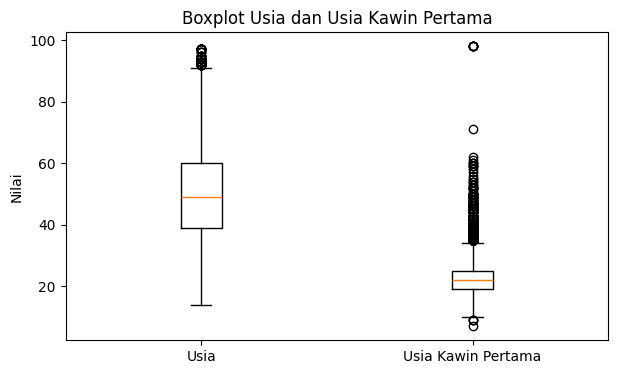

In [25]:
outlier_usia = deteksi_outlier_iqr(df, 'usia')
outlier_usia_kawin = deteksi_outlier_iqr(df, 'usia_kawin_pertama')

plt.figure(figsize=(7,4))
plt.boxplot(
    [df['usia'].dropna(), df['usia_kawin_pertama'].dropna()],
    labels=['Usia', 'Usia Kawin Pertama']
)
plt.title('Boxplot Usia dan Usia Kawin Pertama')
plt.ylabel('Nilai')
plt.show()


In [26]:
#memastikan outlier batas bawah (10) benar adanya atau tidak
df_bawah_10 = df[df['usia_kawin_pertama'] < 10]

print("Jumlah data usia kawin pertama < 10 tahun:", len(df_bawah_10))
df_bawah_10[['usia_kawin_pertama']].value_counts().sort_index()

Jumlah data usia kawin pertama < 10 tahun: 4


,count
usia_kawin_pertama,
7,1
9,3


In [27]:
df_bawah_10.head(10)


,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,usia_kawin_pertama,pendidikan,pekerjaan,pernikahan_dini
11657,4,2,4,2,64,9,25,4,1
18918,7,2,2,2,58,9,3,4,1
47308,16,2,4,2,78,9,25,4,1
55043,19,2,4,2,81,7,3,4,1


In [28]:
kolom = 'usia_kawin_pertama'

Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Batas atas usia kawin pertama:", upper_bound)

# hapus data di atas batas atas
df_clean = df[df[kolom] <= upper_bound]

print("Jumlah data setelah hapus outlier:", df.shape[0])

Batas atas usia kawin pertama: 34.0
Jumlah data setelah hapus outlier: 60084


Kolom: usia
Q1 = 39.0
Q3 = 60.0
IQR = 21.0
Batas bawah = 7.5
Batas atas  = 91.5
Jumlah outlier = 83
----------------------------------------
Kolom: usia_kawin_pertama
Q1 = 19.0
Q3 = 25.0
IQR = 6.0
Batas bawah = 10.0
Batas atas  = 34.0
Jumlah outlier = 4
----------------------------------------


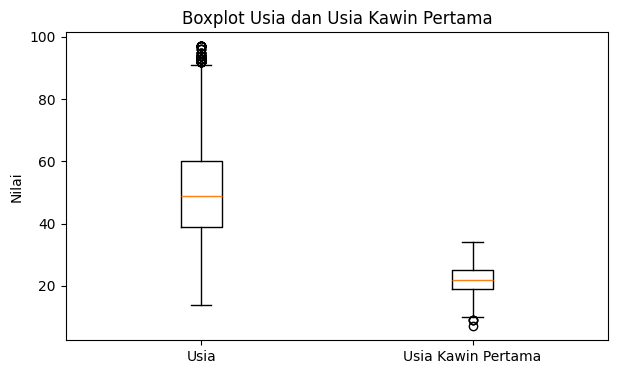

In [29]:
#hanya menghapus outlier batas atas karena batas bawah masih termasuk pernikahan dini dan memang ada pada data
outlier_usia = deteksi_outlier_iqr(df_clean, 'usia')
outlier_usia_kawin = deteksi_outlier_iqr(df_clean, 'usia_kawin_pertama')

plt.figure(figsize=(7,4))
plt.boxplot(
    [df_clean['usia'].dropna(), df_clean['usia_kawin_pertama'].dropna()],
    labels=['Usia', 'Usia Kawin Pertama']
)
plt.title('Boxplot Usia dan Usia Kawin Pertama')
plt.ylabel('Nilai')
plt.show()

Jumlah data tiap kelas setelah preprocessing:
pernikahan_dini
0    45575
1    13168
Name: count, dtype: int64

Persentase tiap kelas:
pernikahan_dini
0    77.583712
1    22.416288
Name: proportion, dtype: float64


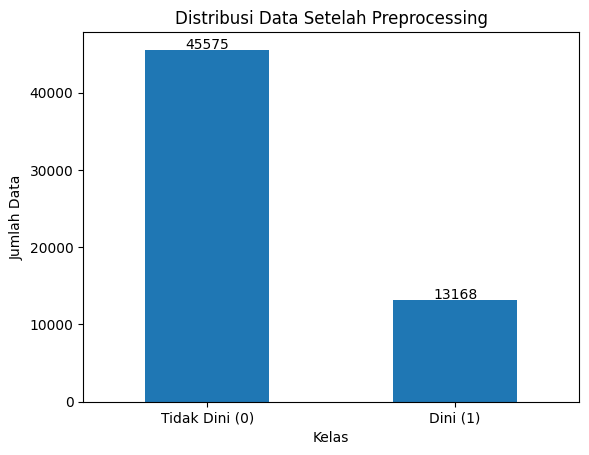

In [30]:
# Gunakan dataset setelah preprocessing
df_clean['pernikahan_dini'] = (df_clean['usia_kawin_pertama'] < 19).astype(int)

# Hapus variabel target dan variabel pembuat target
X = df_clean.drop(columns=['pernikahan_dini', 'usia_kawin_pertama'])
y = df_clean['pernikahan_dini']

# Hitung jumlah kelas
counts = y.value_counts().sort_index()

# Hitung persentase
persen = y.value_counts(normalize=True).sort_index() * 100

# Tampilkan hasil
print("Jumlah data tiap kelas setelah preprocessing:")
print(counts)

print("\nPersentase tiap kelas:")
print(persen)

# Buat grafik
import matplotlib.pyplot as plt

ax = counts.plot(kind='bar')

# Tambahkan angka di atas bar
for i, v in enumerate(counts):
    ax.text(i, v + 100, str(v), ha='center')

plt.title('Distribusi Data Setelah Preprocessing')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.xticks([0,1], ['Tidak Dini (0)', 'Dini (1)'], rotation=0)

plt.show()

EDA HUBUNGAN TARGET

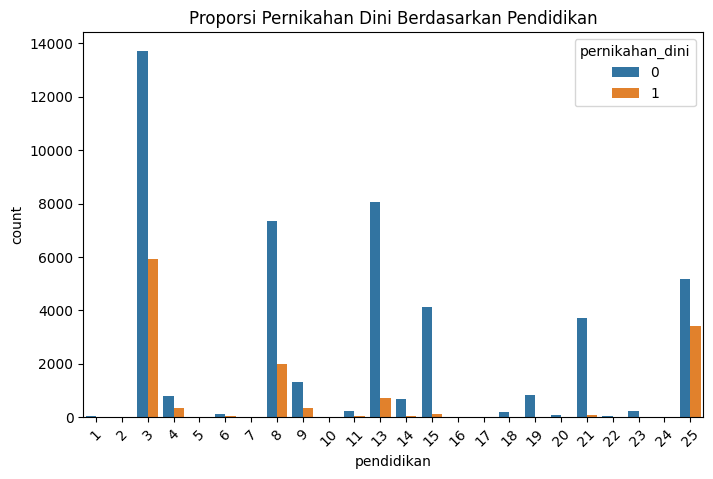

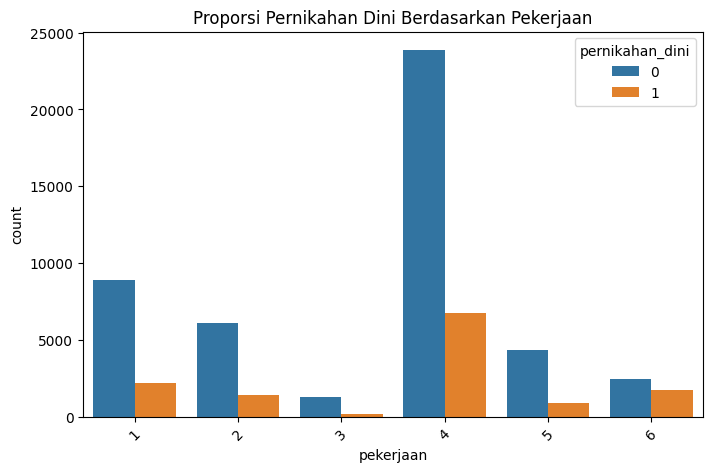

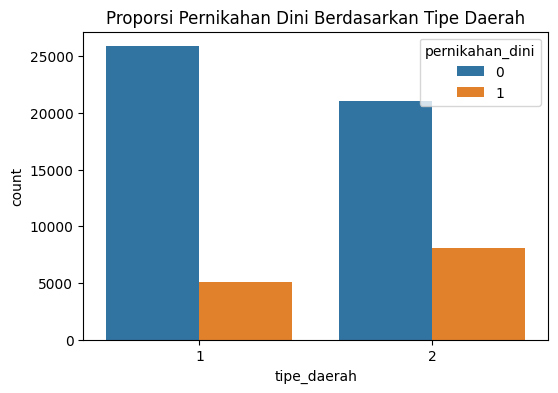

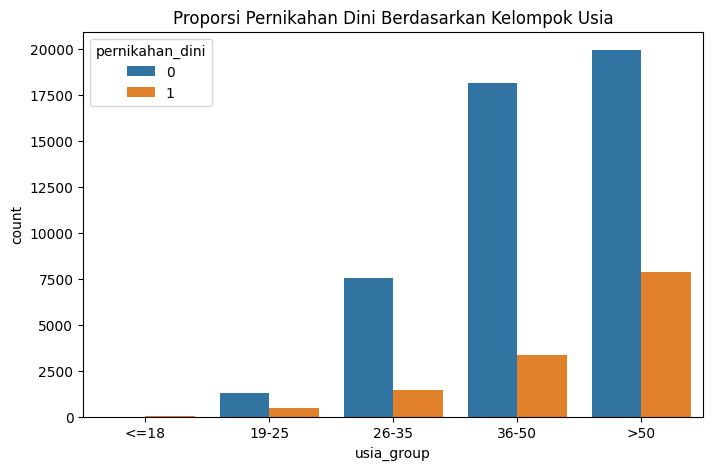

In [31]:
#Proporsi pernikahan dini berdasarkan pendidikan, daerah, kelompok usia
plt.figure(figsize=(8,5))
sns.countplot(x='pendidikan', hue='pernikahan_dini', data=df)
plt.title("Proporsi Pernikahan Dini Berdasarkan Pendidikan")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='pekerjaan', hue='pernikahan_dini', data=df)
plt.title("Proporsi Pernikahan Dini Berdasarkan Pekerjaan")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='tipe_daerah', hue='pernikahan_dini', data=df)
plt.title("Proporsi Pernikahan Dini Berdasarkan Tipe Daerah")
plt.show()

df['usia_group'] = pd.cut(df['usia'], bins=[0,18,25,35,50,100],
                          labels=['<=18','19-25','26-35','36-50','>50'])
plt.figure(figsize=(8,5))
sns.countplot(x='usia_group', hue='pernikahan_dini', data=df)
plt.title("Proporsi Pernikahan Dini Berdasarkan Kelompok Usia")
plt.show()

CRAMERS V

In [32]:
import scipy.stats as ss

def cramers_v(x, y): #mengukur hubungan variabel kategorikal
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Hitung asosiasi untuk fitur kategorikal
cv_pendidikan = cramers_v(df['pendidikan'], df['pernikahan_dini'])
cv_daerah = cramers_v(df['tipe_daerah'], df['pernikahan_dini'])
cv_jk = cramers_v(df['jenis_kelamin'], df['pernikahan_dini'])
cv_pekerjaan = cramers_v(df['pekerjaan'], df['pernikahan_dini'])

print("\n=== Cramer's V dengan Target ===")
print(f"Pendidikan vs Target: {cv_pendidikan:.3f}")
print(f"Tipe Daerah vs Target: {cv_daerah:.3f}")
print(f"Jenis Kelamin vs Target: {cv_jk:.3f}")
print(f"Pekerjaan vs Target: {cv_pekerjaan:.3f}")

#0 = tidak ada hubungan, 1 = hubungan sangat kuat


=== Cramer's V dengan Target ===
Pendidikan vs Target: 0.303
Tipe Daerah vs Target: 0.135
Jenis Kelamin vs Target: 0.375
Pekerjaan vs Target: 0.140


TRANSFORMASI DATA

In [33]:
X.head()

,kab_kota,tipe_daerah,status_kawin,jenis_kelamin,usia,pendidikan,pekerjaan
0,1,2,2,1,39,13,5
1,1,1,2,2,28,3,4
2,1,1,2,1,51,3,5
3,1,2,2,2,40,8,1
4,1,2,2,2,30,8,4


MAPPING

In [34]:
pendidikan_map = {
    1: "Paket A", 2: "SDLB", 3: "SD", 4: "MI", 5: "SPM/PDF Ula",
    6: "Paket B", 7: "SMP LB", 8: "SMP", 9: "MTs", 10: "SPM/PDF Wustha",
    11: "Paket C", 12: "SMLB", 13: "SMA", 14: "MA", 15: "SMK",
    16: "MAK", 17: "SPM/PDF Ulya", 18: "D1/D2", 19: "D3", 20: "D4",
    21: "S1", 22: "Profesi", 23: "S2", 24: "S3",
    25: "Tidak Punya Ijazah SD"
}

df['pendidikan'] = df['pendidikan'].map(pendidikan_map)

In [35]:
pekerjaan_map = {
    1: "Berusaha sendiri",
    2: "Dibantu tidak tetap",
    3: "Dibantu tetap",
    4: "Buruh",
    5: "Pekerja bebas",
    6: "Tidak dibayar"
}

df['pekerjaan'] = df['pekerjaan'].map(pekerjaan_map)

In [36]:
jk_map = {
    1: "laki-laki",
    2: "perempuan"
}

df['jenis_kelamin'] = df['jenis_kelamin'].map(jk_map)

In [37]:
kab_map = {
    1: "CILACAP", 2: "BANYUMAS", 3: "PURBALINGGA", 4: "BANJARNEGARA",
    5: "KEBUMEN", 6: "PURWOREJO", 7: "WONOSOBO", 8: "KAB_MAGELANG",
    9: "BOYOLALI", 10: "KLATEN", 11: "SUKOHARJO", 12: "WONOGIRI",
    13: "KARANGANYAR", 14: "SRAGEN", 15: "GROBOGAN", 16: "BLORA",
    17: "REMBANG", 18: "PATI", 19: "KUDUS", 20: "JEPARA",
    21: "DEMAK", 22: "KAB_SEMARANG", 23: "TEMANGGUNG", 24: "KENDAL",
    25: "BATANG", 26: "KAB_PEKALONGAN", 27: "PEMALANG", 28: "KAB_TEGAL",
    29: "BREBES",
    71: "KOTA_MAGELANG", 72: "SURAKARTA", 73: "SALATIGA",
    74: "KOTA_SEMARANG", 75: "KOTA_PEKALONGAN", 76: "KOTA_TEGAL"
}

df['kab_kota'] = df['kab_kota'].map(kab_map)

In [38]:
daerah_map = {
    1: "perkotaan",
    2: "pedesaan"
}

df['tipe_daerah'] = df['tipe_daerah'].map(daerah_map)

In [39]:
kawin_map = {
    1: "Belum kawin",
    2: "Kawin",
    3: "Cerai hidup",
    4: "Cerai mati"
}

df['status_kawin'] = df['status_kawin'].map(kawin_map)

ENCODE

In [40]:
#Ordinal Encoder untuk pendidikan karena mempunyai tingkatan khusus
pendidikan_order = [
    "Tidak Punya Ijazah SD",
    "SDLB", "SD", "MI", "SPM/PDF Ula", "Paket A",
    "SMP LB", "SMP", "MTs", "SPM/PDF Wustha", "Paket B",
    "SMA", "MA", "SMK", "MAK", "SPM/PDF Ulya", "Paket C", "SMLB",
    "D1/D2", "D3", "D4", "S1", "Profesi", "S2", "S3"
]

oe_pendidikan = OrdinalEncoder(categories=[pendidikan_order])

df['pendidikan_encoded'] = oe_pendidikan.fit_transform(df[['pendidikan']])

In [41]:
#one-hot encoder karena setiap fitur bernilai sama/tidak ada tingkatan
ohe = OneHotEncoder(sparse_output=False)

cols_ohe = ['pekerjaan', 'kab_kota', 'status_kawin']
encoded = ohe.fit_transform(df[cols_ohe])

df_ohe = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols_ohe)
)

df = pd.concat([df, df_ohe], axis=1)

In [42]:
ohe_kab = OneHotEncoder(sparse_output=False)

kab_encoded = ohe_kab.fit_transform(df[['kab_kota']])

df_kab = pd.DataFrame(
    kab_encoded,
    columns=ohe_kab.get_feature_names_out(['kab_kota'])
)

df = pd.concat([df, df_kab], axis=1)

In [43]:
ohe_kawin = OneHotEncoder(sparse_output=False)

kawin_encoded = ohe_kawin.fit_transform(df[['status_kawin']])

df_kawin = pd.DataFrame(
    kawin_encoded,
    columns=ohe_kawin.get_feature_names_out(['status_kawin'])
)

df = pd.concat([df, df_kawin], axis=1)

In [44]:
ohe_jk = OneHotEncoder(sparse_output=False)

jk_encoded = ohe_jk.fit_transform(df[['jenis_kelamin']])

df_jk = pd.DataFrame(
    jk_encoded,
    columns=ohe_jk.get_feature_names_out(['jenis_kelamin'])
)

df = pd.concat([df, df_jk], axis=1)

In [45]:
ohe_daerah = OneHotEncoder(sparse_output=False)

daerah_encoded = ohe_daerah.fit_transform(df[['tipe_daerah']])

df_daerah = pd.DataFrame(
    daerah_encoded,
    columns=ohe_daerah.get_feature_names_out(['tipe_daerah'])
)

df = pd.concat([df, df_daerah], axis=1)

In [46]:
df = df.drop(['pekerjaan', 'jenis_kelamin', 'kab_kota', 'tipe_daerah', 'status_kawin'], axis=1)

In [47]:
df.columns

Index(['usia', 'usia_kawin_pertama', 'pendidikan', 'pernikahan_dini',
       'usia_group', 'pendidikan_encoded', 'pekerjaan_Berusaha sendiri',
       'pekerjaan_Buruh', 'pekerjaan_Dibantu tetap',
       'pekerjaan_Dibantu tidak tetap', 'pekerjaan_Pekerja bebas',
       'pekerjaan_Tidak dibayar', 'kab_kota_BANJARNEGARA', 'kab_kota_BANYUMAS',
       'kab_kota_BATANG', 'kab_kota_BLORA', 'kab_kota_BOYOLALI',
       'kab_kota_BREBES', 'kab_kota_CILACAP', 'kab_kota_DEMAK',
       'kab_kota_GROBOGAN', 'kab_kota_JEPARA', 'kab_kota_KAB_MAGELANG',
       'kab_kota_KAB_PEKALONGAN', 'kab_kota_KAB_SEMARANG',
       'kab_kota_KAB_TEGAL', 'kab_kota_KARANGANYAR', 'kab_kota_KEBUMEN',
       'kab_kota_KENDAL', 'kab_kota_KLATEN', 'kab_kota_KOTA_MAGELANG',
       'kab_kota_KOTA_PEKALONGAN', 'kab_kota_KOTA_SEMARANG',
       'kab_kota_KOTA_TEGAL', 'kab_kota_KUDUS', 'kab_kota_PATI',
       'kab_kota_PEMALANG', 'kab_kota_PURBALINGGA', 'kab_kota_PURWOREJO',
       'kab_kota_REMBANG', 'kab_kota_SALATIGA', 'kab_

In [48]:
numerical = ['usia']

ordinal = ['pendidikan']

categorical = [
    'pekerjaan',
    'jenis_kelamin',
    'kab_kota',
    'tipe_daerah',
    'status_kawin'
]

In [49]:
preprocessor_rf = ColumnTransformer( #ColumnTransformer = mnerapkan preprocessing berbeda pada tiap kolom, pada tahap ini trasnformasi
    transformers=[
        ('all', 'passthrough', numerical + ordinal + categorical)
    ]
)

In [50]:
preprocessor_svm = ColumnTransformer([
    ('cat_nominal', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('cat_ordinal', OrdinalEncoder(), ordinal),
    ('num', 'passthrough', numerical)
])

Distribusi Undersampling

In [51]:
from imblearn.under_sampling import TomekLinks #import tomeklink

random = RandomUnderSampler() #Randomundersampling lebih efisien dan umum digunakan untuk dataset imbalanced ekstrem karena mampu menyeimbangkan data 1:1

X_random, y_random = random.fit_resample(X, y)

print("Distribusi setelah Tomek Links:")
print(y_random.value_counts())

Distribusi setelah Tomek Links:
pernikahan_dini
0    13168
1    13168
Name: count, dtype: int64


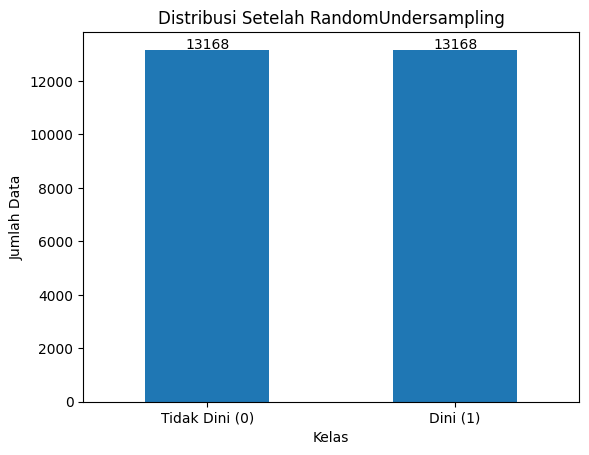

In [52]:
import matplotlib.pyplot as plt

counts = y_random.value_counts().sort_index()

ax = counts.plot(kind='bar')

for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center')

plt.title("Distribusi Setelah RandomUndersampling")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks([0,1], ['Tidak Dini (0)', 'Dini (1)'], rotation=0)

plt.show()

In [53]:
from imblearn.under_sampling import TomekLinks #Tomek Link tidak dapat menyeimbangkan data 1:1
#maka dijadikan hybrid dengan RUS dengan tujuan dataset tidak hanya imbang namun bersih thdp noise

tomek = TomekLinks()

X_combined, y_combined = tomek.fit_resample(X_random, y_random) #hasil rus + tomek

print("Distribusi setelah Tomek Links:")
print(y_combined.value_counts())

Distribusi setelah Tomek Links:
pernikahan_dini
0    13168
1    11951
Name: count, dtype: int64


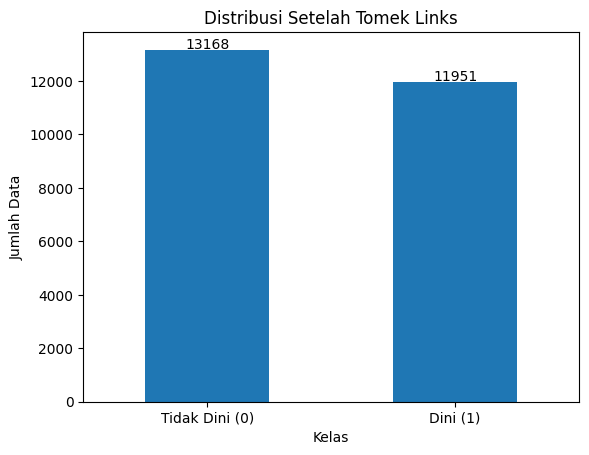

In [54]:
import matplotlib.pyplot as plt

counts = y_combined.value_counts().sort_index()

ax = counts.plot(kind='bar')

for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center')

plt.title("Distribusi Setelah Tomek Links")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks([0,1], ['Tidak Dini (0)', 'Dini (1)'], rotation=0)

plt.show()

PIPELINE BASELINE

In [55]:
pipeline_rf = SkPipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42))
])


In [56]:
import numpy as np
from sklearn.svm import SVC, LinearSVC

pipeline_svm = SkPipeline([
    ('preprocess', preprocessor_svm),
    ('scaler', StandardScaler(with_mean=False)), #with_mean=False, digunakan karena data mengandung sparse matrix setelah one hot sehingga dapat meningkastkan penggunaan memory
    ('classifier', LinearSVC(max_iter=5000)) #Nilai max_iter diperbesar menjadi 5000 untuk memastikan proses optimisasi SVM mencapai konvergensi(stabil)
])


In [57]:
pipeline_svm_RBF = SkPipeline([
    ('preprocess', preprocessor_svm),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(kernel='rbf')) #karena menggunakan SVC model akan berhenti ketika sudah mencapai konvergensi sendiri
])


RANDOM UNDERSAMPLER

In [58]:
pipeline_random_rf = ImbPipeline([ #penggunaan ImbPipeline karena terdapat resampling
    ('preprocessor', preprocessor_rf),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
    ))
])

In [59]:
pipeline_random_svm = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',LinearSVC(
        max_iter=5000,
        C=1, #default
        random_state=42
    ))
])

In [60]:
pipeline_random_RBF_svm = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(
        kernel='RBF',
        C=1,
        random_state=42
    ))
])


*RUS + TomekLinks*

In [61]:
pipeline_rf_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('undersampler', TomekLinks()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [62]:
pipeline_svm_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', TomekLinks()),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',LinearSVC(max_iter=5000,
        C=1,
        random_state=42
    ))
])

In [63]:
pipeline_svm_RBF_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(
        kernel='RBF',
        C=1,
        random_state=42
    ))
])

Fungsi Evaluasi

In [64]:
def evaluate_pipeline(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train) #model belajar data training
    y_pred = pipe.predict(X_test) #model menebak data testing

    # ROC AUC
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'): #cek apakah classifier punya fungsi tertentu
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test) #jarak model terhadap boundary

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score), #kemampuan model membedakan kelas
        "mcc": matthews_corrcoef(y_test, y_pred), #lebih stabil untuk data imbalance
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

In [65]:
results = []

In [66]:
test_sizes = [0.1, 0.2, 0.3] #digunakan beberapa untuk melihat kestabilan model pada proporsi yang berbeda

In [67]:
pipelines_rf = [
    ("RF", "Baseline", pipeline_rf),
    ("RF", "RandomUnder", pipeline_random_rf),
    ("RF", "hybrid", pipeline_rf_hybrid),
]

In [68]:
for ts in test_sizes: #loop test size
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_rf:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [69]:
pipelines_svm =[
    ("SVM", "Baseline", pipeline_svm),
]

In [70]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_svm:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [71]:
pipelines_svm_random =[
    ("SVM", "RandomUnder", pipeline_random_svm),
]

In [72]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_svm_random:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [73]:
pipelines_svm_hybrid= [
    ("SVM", "hybrid", pipeline_svm_hybrid),
]

In [74]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_svm_hybrid:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [75]:
pipelines_rbf = [
    ("SVM RBF", "Baseline", pipeline_svm),
]

In [76]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_rbf:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [77]:
pipelines_rbf_random = [
    ("SVM RBF", "RandomUnder", pipeline_random_svm),
]

In [78]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_rbf_random:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [79]:
pipelines_rbf_hybrid = [
    ("SVM RBF", "hybrid", pipeline_svm_hybrid),
]

In [80]:
for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        stratify=y,
        random_state=42
    )

    for model, scenario, pipe in pipelines_rbf_hybrid:
        metrics = evaluate_pipeline(pipe, X_train, X_test, y_train, y_test)

        results.append({
            "model": model,
            "scenario": scenario,
            "test_size": ts,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "mcc": metrics["mcc"],
            "confusion_matrix": metrics["confusion_matrix"]
        })


In [81]:
results_df = pd.DataFrame(results)
results_df

,model,scenario,test_size,accuracy,precision,recall,f1,roc_auc,mcc,confusion_matrix
0,RF,Baseline,0.1,0.776851,0.502564,0.446469,0.472859,0.791369,0.332890,"[[3976, 582], [729, 588]]"
1,RF,RandomUnder,0.1,0.731745,0.441640,0.744115,0.554299,0.803108,0.406259,"[[3319, 1239], [337, 980]]"
2,RF,hybrid,0.1,0.778213,0.505538,0.485194,0.495157,0.794895,0.353247,"[[3933, 625], [678, 639]]"
3,RF,Baseline,0.2,0.777002,0.503033,0.440774,0.469850,0.792658,0.330586,"[[7968, 1147], [1473, 1161]]"
4,RF,RandomUnder,0.2,0.728232,0.438368,0.754746,0.554610,0.805076,0.407185,"[[6568, 2547], [646, 1988]]"
5,RF,hybrid,0.2,0.779726,0.509178,0.484434,0.496498,0.797097,0.355817,"[[7885, 1230], [1358, 1276]]"
6,RF,Baseline,0.3,0.779322,0.508853,0.443797,0.474104,0.790176,0.336547,"[[11981, 1692], [2197, 1753]]"
7,RF,RandomUnder,0.3,0.729501,0.438838,0.742025,0.551510,0.801157,0.402205,"[[9925, 3748], [1019, 2931]]"
8,RF,hybrid,0.3,0.780060,0.509952,0.480000,0.494523,0.795944,0.354405,"[[11851, 1822], [2054, 1896]]"
9,SVM,Baseline,0.1,0.801191,0.614089,0.304480,0.407107,0.819548,0.330628,"[[4306, 252], [916, 401]]"


In [82]:
subset = results_df[results_df['test_size'] == 0.2].copy()
subset['label'] = subset['model'] + ' - ' + subset['scenario']

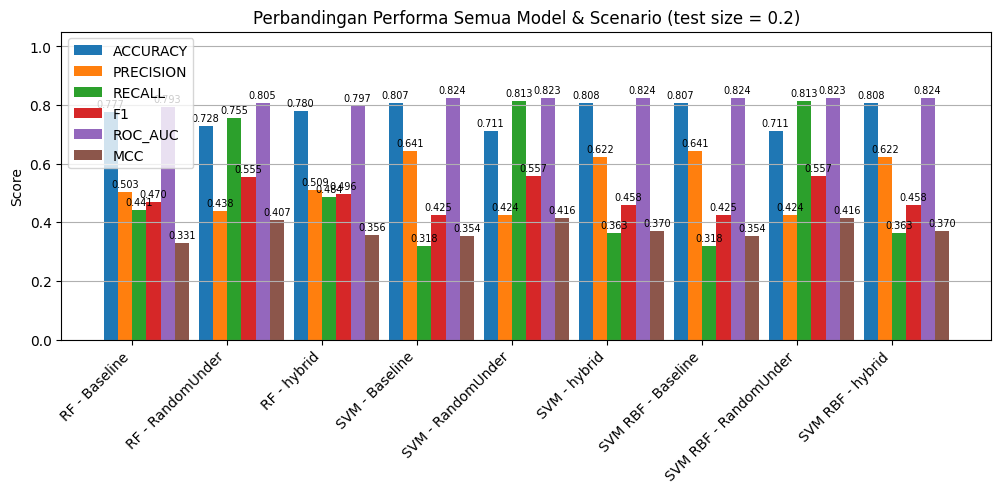

In [83]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc']
labels = subset['label'].values
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12,4))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + i*width,
        subset[metric],
        width,
        label=metric.upper()
    )

    # Tambahkan angka di atas bar
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Semua Model & Scenario (test size = 0.2)')
ax.legend()
ax.grid(axis='y')

plt.ylim(0,1.05)

plt.show()

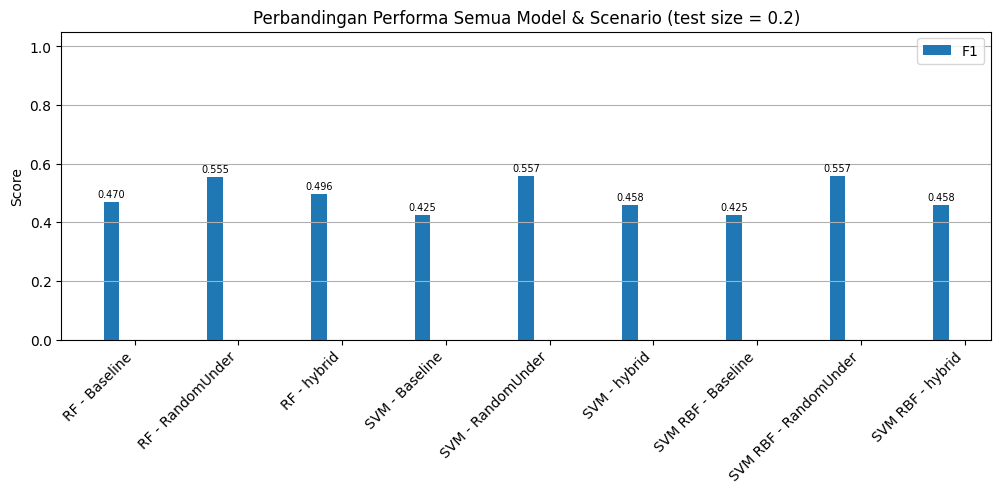

In [84]:
metrics = ['f1']
labels = subset['label'].values
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12,4))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + i*width,
        subset[metric],
        width,
        label=metric.upper()
    )

    # Tambahkan angka di atas bar
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Semua Model & Scenario (test size = 0.2)')
ax.legend()
ax.grid(axis='y')

plt.ylim(0,1.05)

plt.show()

In [85]:
def plot_roc_curve(pipe, X_train, X_test, y_train, y_test, label):
    pipe.fit(X_train, y_train)

    if hasattr(pipe.named_steps['classifier'], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

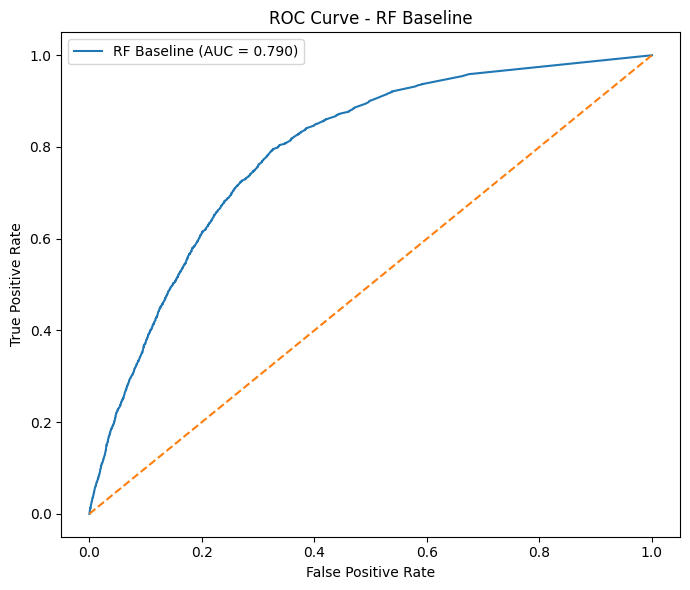

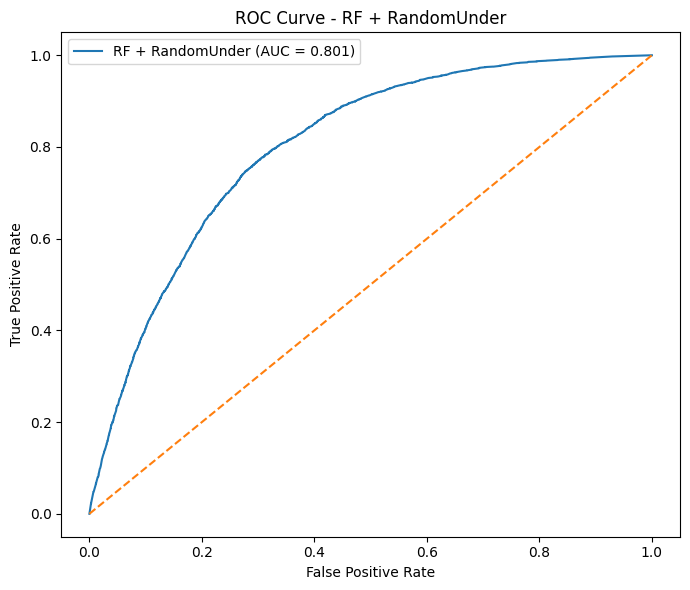

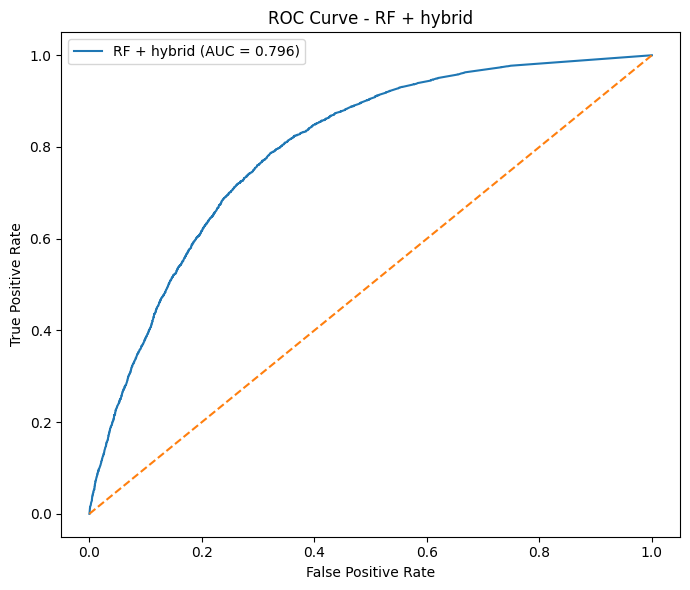

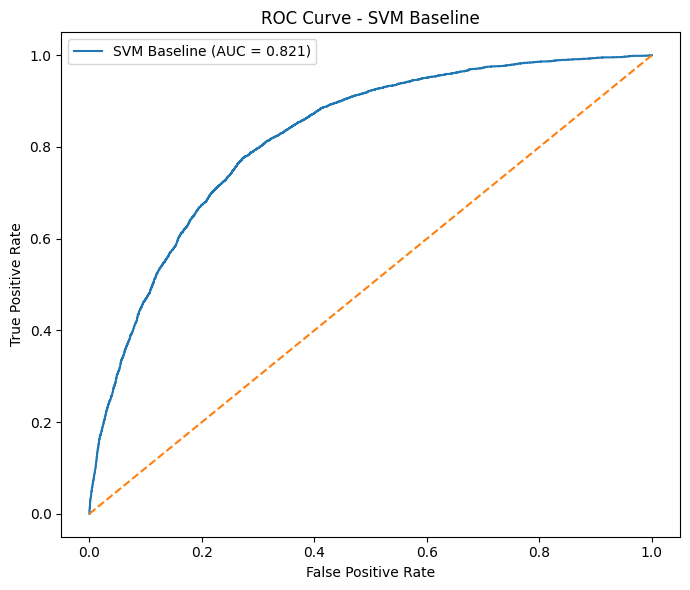

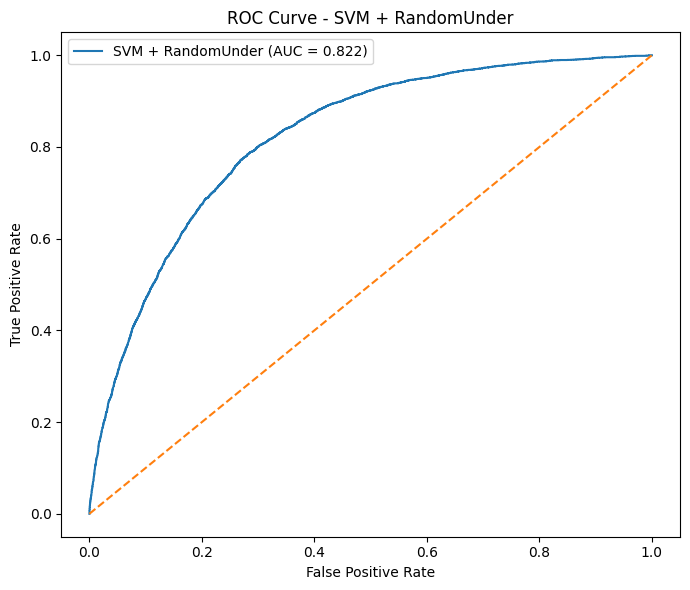

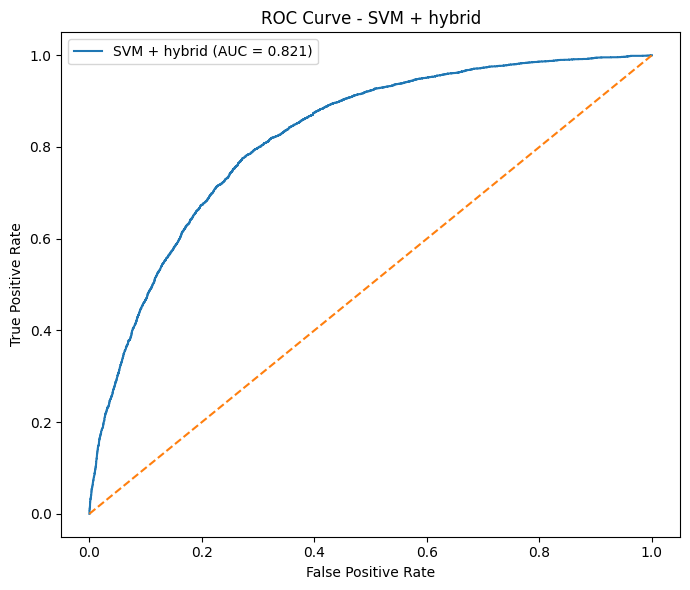

In [86]:
models = [
    (pipeline_rf, "RF Baseline"),
    (pipeline_random_rf, "RF + RandomUnder"),
    (pipeline_rf_hybrid, "RF + hybrid"),
    (pipeline_svm, "SVM Baseline"),
    (pipeline_random_svm, "SVM + RandomUnder"),
    (pipeline_svm_hybrid, "SVM + hybrid"),
]

for pipe, label in models:
    plt.figure(figsize=(7,6))

    plot_roc_curve(pipe, X_train, X_test, y_train, y_test, label)

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"ROC Curve - {label}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [87]:
def plot_confusion_matrix(pipe, X_train, X_test, y_train, y_test, title):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    ig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, cmap='Blues')

    # Label
    ax.set_title(title, pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Tidak Dini', 'Dini'])
    ax.set_yticklabels(['Tidak Dini', 'Dini'])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=11
            )

    plt.tight_layout()
    plt.show()

    return cm

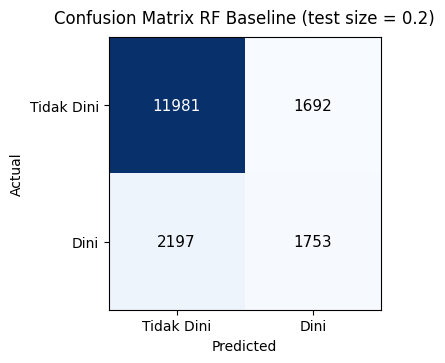

array([[11981,  1692],
       [ 2197,  1753]])

In [88]:
plot_confusion_matrix(
    pipeline_rf,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix RF Baseline (test size = 0.2)'
)

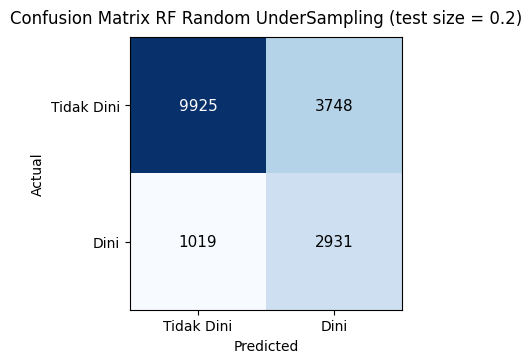

array([[9925, 3748],
       [1019, 2931]])

In [89]:
plot_confusion_matrix(
    pipeline_random_rf,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix RF Random UnderSampling (test size = 0.2)'
)

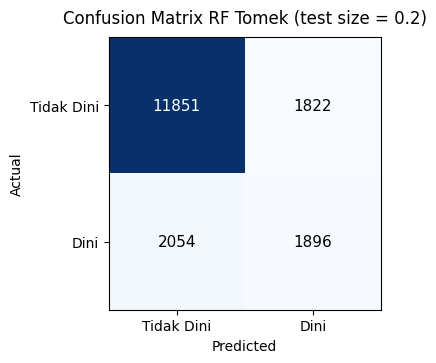

array([[11851,  1822],
       [ 2054,  1896]])

In [90]:
plot_confusion_matrix(
    pipeline_rf_hybrid,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix RF Tomek (test size = 0.2)'
)

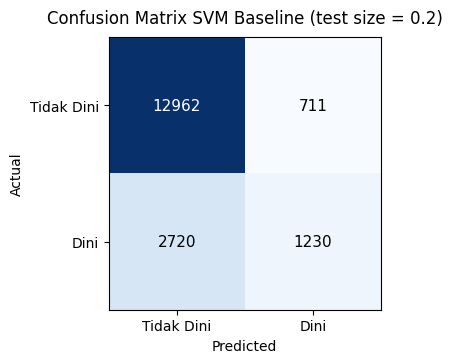

array([[12962,   711],
       [ 2720,  1230]])

In [91]:
plot_confusion_matrix(
    pipeline_svm,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix SVM Baseline (test size = 0.2)'
)

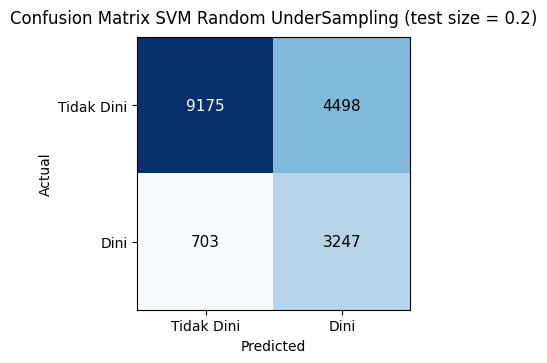

array([[9175, 4498],
       [ 703, 3247]])

In [92]:
plot_confusion_matrix(
    pipeline_random_svm,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix SVM Random UnderSampling (test size = 0.2)'
)

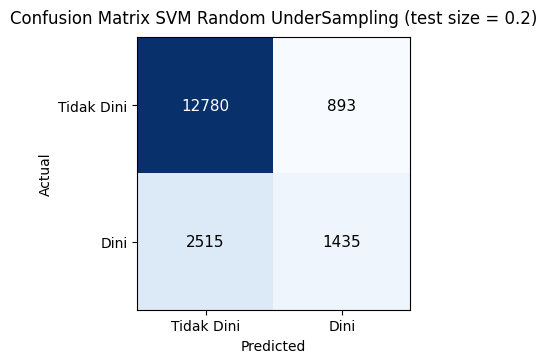

array([[12780,   893],
       [ 2515,  1435]])

In [93]:
plot_confusion_matrix(
    pipeline_svm_hybrid,
    X_train, X_test, y_train, y_test,
    title='Confusion Matrix SVM Random UnderSampling (test size = 0.2)'
)

TUNING

In [94]:
param_grid_rf= {
    'classifier__n_estimators': [100, 200], #umum dipakai, cukup stabil
    'classifier__max_depth': [None, 10, 20], #pohon tumbuh bebas, membatasi 10,20 terlalu dalam overfit, terlalu dangkal undervit
    'classifier__min_samples_split': [2, 5], #mengontrol pemecahan node agar tidak terlalu kompleks
    'classifier__min_samples_leaf': [1, 2], #mencari generalisasi terbaik
    'classifier__max_features': ['sqrt'] #umum dipakai utk meningkatkan keragaman
}

In [95]:
param_grid_linear_svm = {
    'classifier__C': [0.1, 1, 10] #toleransi kesalahan model. 0,1 longgar. 10 ketat
    #gamma hanya untuk non-linear
}

param_grid_rbf_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf'],
    'classifier__gamma': ['scale'] #gamma dihitung otomatis berdasarkan variance dan jumlah data
    #stabil, mengurangi risiko gamma terlalu ekstrem
}

In [96]:
def tuning_model(pipeline, param_grid, X_train, y_train, model_name):
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,#mencoba semua kombinasi parameter
        scoring='f1',#data imbalanced, menyeimbangkan precision dan recall
        cv=3, #stabil dan ringan, kenapa ga 10? training berat, banyak kombinasi dan banyak model
        n_jobs=-1, #proses tuning lebih cepat
        verbose=2, #utk melihat progress tuning
        error_score='raise' #melihat langsung error, agar mudah debugging
    )

    grid.fit(X_train, y_train)

    print(f"\n=== {model_name} ===")
    print("Best Params:", grid.best_params_)
    print("Best F1 Score:", grid.best_score_)

    return grid.best_estimator_

In [97]:
pipeline_rf = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [98]:
pipeline_random_rf = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [99]:
pipeline_rf_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('undersampler', TomekLinks()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [100]:
pipeline_svm = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', LinearSVC(max_iter=5000, random_state=42))
])

In [101]:
pipeline_random_svm = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', LinearSVC(max_iter=5000, random_state=42))
])

In [102]:
pipeline_svm_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', TomekLinks()),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', LinearSVC(max_iter=5000, random_state=42))
])

In [103]:
pipeline_svm_RBF = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

In [104]:
pipeline_random_RBF_svm = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

In [105]:
pipeline_svm_RBF_hybrid = ImbPipeline([
    ('preprocessor', preprocessor_svm),
    ('undersampler', TomekLinks()),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

In [106]:
# RF
best_rf = tuning_model(pipeline_rf, param_grid_rf, X_train, y_train, "RF Baseline")
best_rf_random = tuning_model(pipeline_random_rf, param_grid_rf, X_train, y_train, "RF + RandomUnder")
best_rf_hybrid = tuning_model(pipeline_rf_hybrid, param_grid_rf, X_train, y_train, "RF + Hybrid")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== RF Baseline ===
Best Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best F1 Score: 0.5029563006901064
Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== RF + RandomUnder ===
Best Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best F1 Score: 0.6023788133640079
Fitting 3 folds for each of 24 candidates, totalling 72 fits

=== RF + Hybrid ===
Best Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best F1 Score: 0.5280859974071702


min samples leaf =2, 1 terlalu spesifik dan overfitting.
min samples split =2, model masih membutuhkan split agresif untuk mempelajari pola.
n_estimator 100 sudah cukup stabil.

max depth randomundersampling berbeda?? karena data lebih seimbang jadi phon tidak butuh terlalu kompleks karena kelas minoritas sudah terlihat, F1 nya pun paling tinggi. Balancing efektif

In [107]:
# SVM
best_svm = tuning_model(pipeline_svm, param_grid_linear_svm, X_train, y_train, "SVM Baseline")
best_svm_random = tuning_model(pipeline_random_svm, param_grid_linear_svm, X_train, y_train, "SVM + RandomUnder")
best_svm_hybrid = tuning_model(pipeline_svm_hybrid, param_grid_linear_svm, X_train, y_train, "SVM + Hybrid")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM Baseline ===
Best Params: {'classifier__C': 1}
Best F1 Score: 0.41403724689689936
Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM + RandomUnder ===
Best Params: {'classifier__C': 1}
Best F1 Score: 0.5616594120208643
Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM + Hybrid ===
Best Params: {'classifier__C': 10}
Best F1 Score: 0.4582897846250786


C=1 terbaik memberikan keseimbangan yang optimal jika 0,1 model terlalu longgar dapat menyebabkan underfitting.

Random Undersampling F1 naik, berhasil memperbaiki batas svm, hyperplane lebih adil karena kelas minoritas terlihat. C tetap 1 artinya perubahan distribusi data lebih berpengaruh dibanding perubahan nilai C

Hybrid C =10? karena hybrid menghapus data noise menjadikan batas lebih rumit, nilai C yang besar membantu membentuk garis yang lebih detail. tetapi F1 tetap lebih kecil dari Random Undersampling. Ternyata batas terlalu kompleks belum tentu terbaik



In [108]:
# SVM RBF
best_svm_rbf = tuning_model(pipeline_svm_RBF, param_grid_rbf_svm, X_train, y_train, "SVM Baseline")
best_svm__rbf_random = tuning_model(pipeline_random_RBF_svm, param_grid_rbf_svm, X_train, y_train, "SVM + RandomUnder")
best_svm_rbf_hybrid = tuning_model(pipeline_svm_RBF_hybrid, param_grid_rbf_svm, X_train, y_train, "SVM + Hybrid")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM Baseline ===
Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 Score: 0.44651882140616656
Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM + RandomUnder ===
Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 Score: 0.5719126329780679
Fitting 3 folds for each of 3 candidates, totalling 9 fits

=== SVM + Hybrid ===
Best Params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 Score: 0.4847967094981127


Hasil RBF berbeda dengn linear = ada kemungkinan data non-linear

nilai C terbaik 10, karena RBF fleksibel jika 0,1, model bisa terlalu santai, RBF butuh lebih tegas

SVM RBF lebih baik dari linear artinya data tidak sepenuhnya linear

hubungan faktor sosial ekonomi dengan pernikahan dini tidak sederhana karena model non-linear bekerja lebih baik

In [109]:
results = []

models = [
    ("RF Baseline", best_rf),
    ("RF RandomUnder", best_rf_random),
    ("RF Hybrid", best_rf_hybrid),
    ("SVM Baseline", best_svm),
    ("SVM RandomUnder", best_svm_random),
    ("SVM Hybrid", best_svm_hybrid),
    ("SVM RBF Baseline", best_svm_rbf),
    ("SVM RBF RandomUnder", best_svm__rbf_random),
    ("SVM RBF Hybrid", best_svm_rbf_hybrid),
]

for name, model in models:
    res = evaluate_pipeline(model, X_train, X_test, y_train, y_test)
    res['label'] = name
    results.append(res)

df_compare = pd.DataFrame(results)

In [110]:
untuned_subset = results_df[results_df['test_size'] == 0.2].copy()
untuned_subset['label'] = untuned_subset['model'] + ' ' + untuned_subset['scenario'] + ' (Untuned)'

tuned_full_results = df_compare.copy()
tuned_full_results['label'] = tuned_full_results['label'] + ' (Tuned)'

metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc']

combined_full_results = pd.concat(
    [untuned_subset[['label'] + metrics_to_compare],
     tuned_full_results[['label'] + metrics_to_compare]],
    ignore_index=True
)

display(combined_full_results)

,label,accuracy,precision,recall,f1,roc_auc,mcc
0,RF Baseline (Untuned),0.777002,0.503033,0.440774,0.469850,0.792658,0.330586
1,RF RandomUnder (Untuned),0.728232,0.438368,0.754746,0.554610,0.805076,0.407185
2,RF hybrid (Untuned),0.779726,0.509178,0.484434,0.496498,0.797097,0.355817
3,SVM Baseline (Untuned),0.807218,0.641163,0.318147,0.425273,0.823523,0.353728
4,SVM RandomUnder (Untuned),0.710529,0.424044,0.812832,0.557334,0.823454,0.416002
5,SVM hybrid (Untuned),0.807643,0.621745,0.362566,0.458034,0.823551,0.369685
6,SVM RBF Baseline (Untuned),0.807218,0.641163,0.318147,0.425273,0.823523,0.353728
7,SVM RBF RandomUnder (Untuned),0.710529,0.424044,0.812832,0.557334,0.823454,0.416002
8,SVM RBF hybrid (Untuned),0.807643,0.621745,0.362566,0.458034,0.823551,0.369685
9,RF Baseline (Tuned),0.802361,0.577704,0.439494,0.499209,0.832750,0.384412


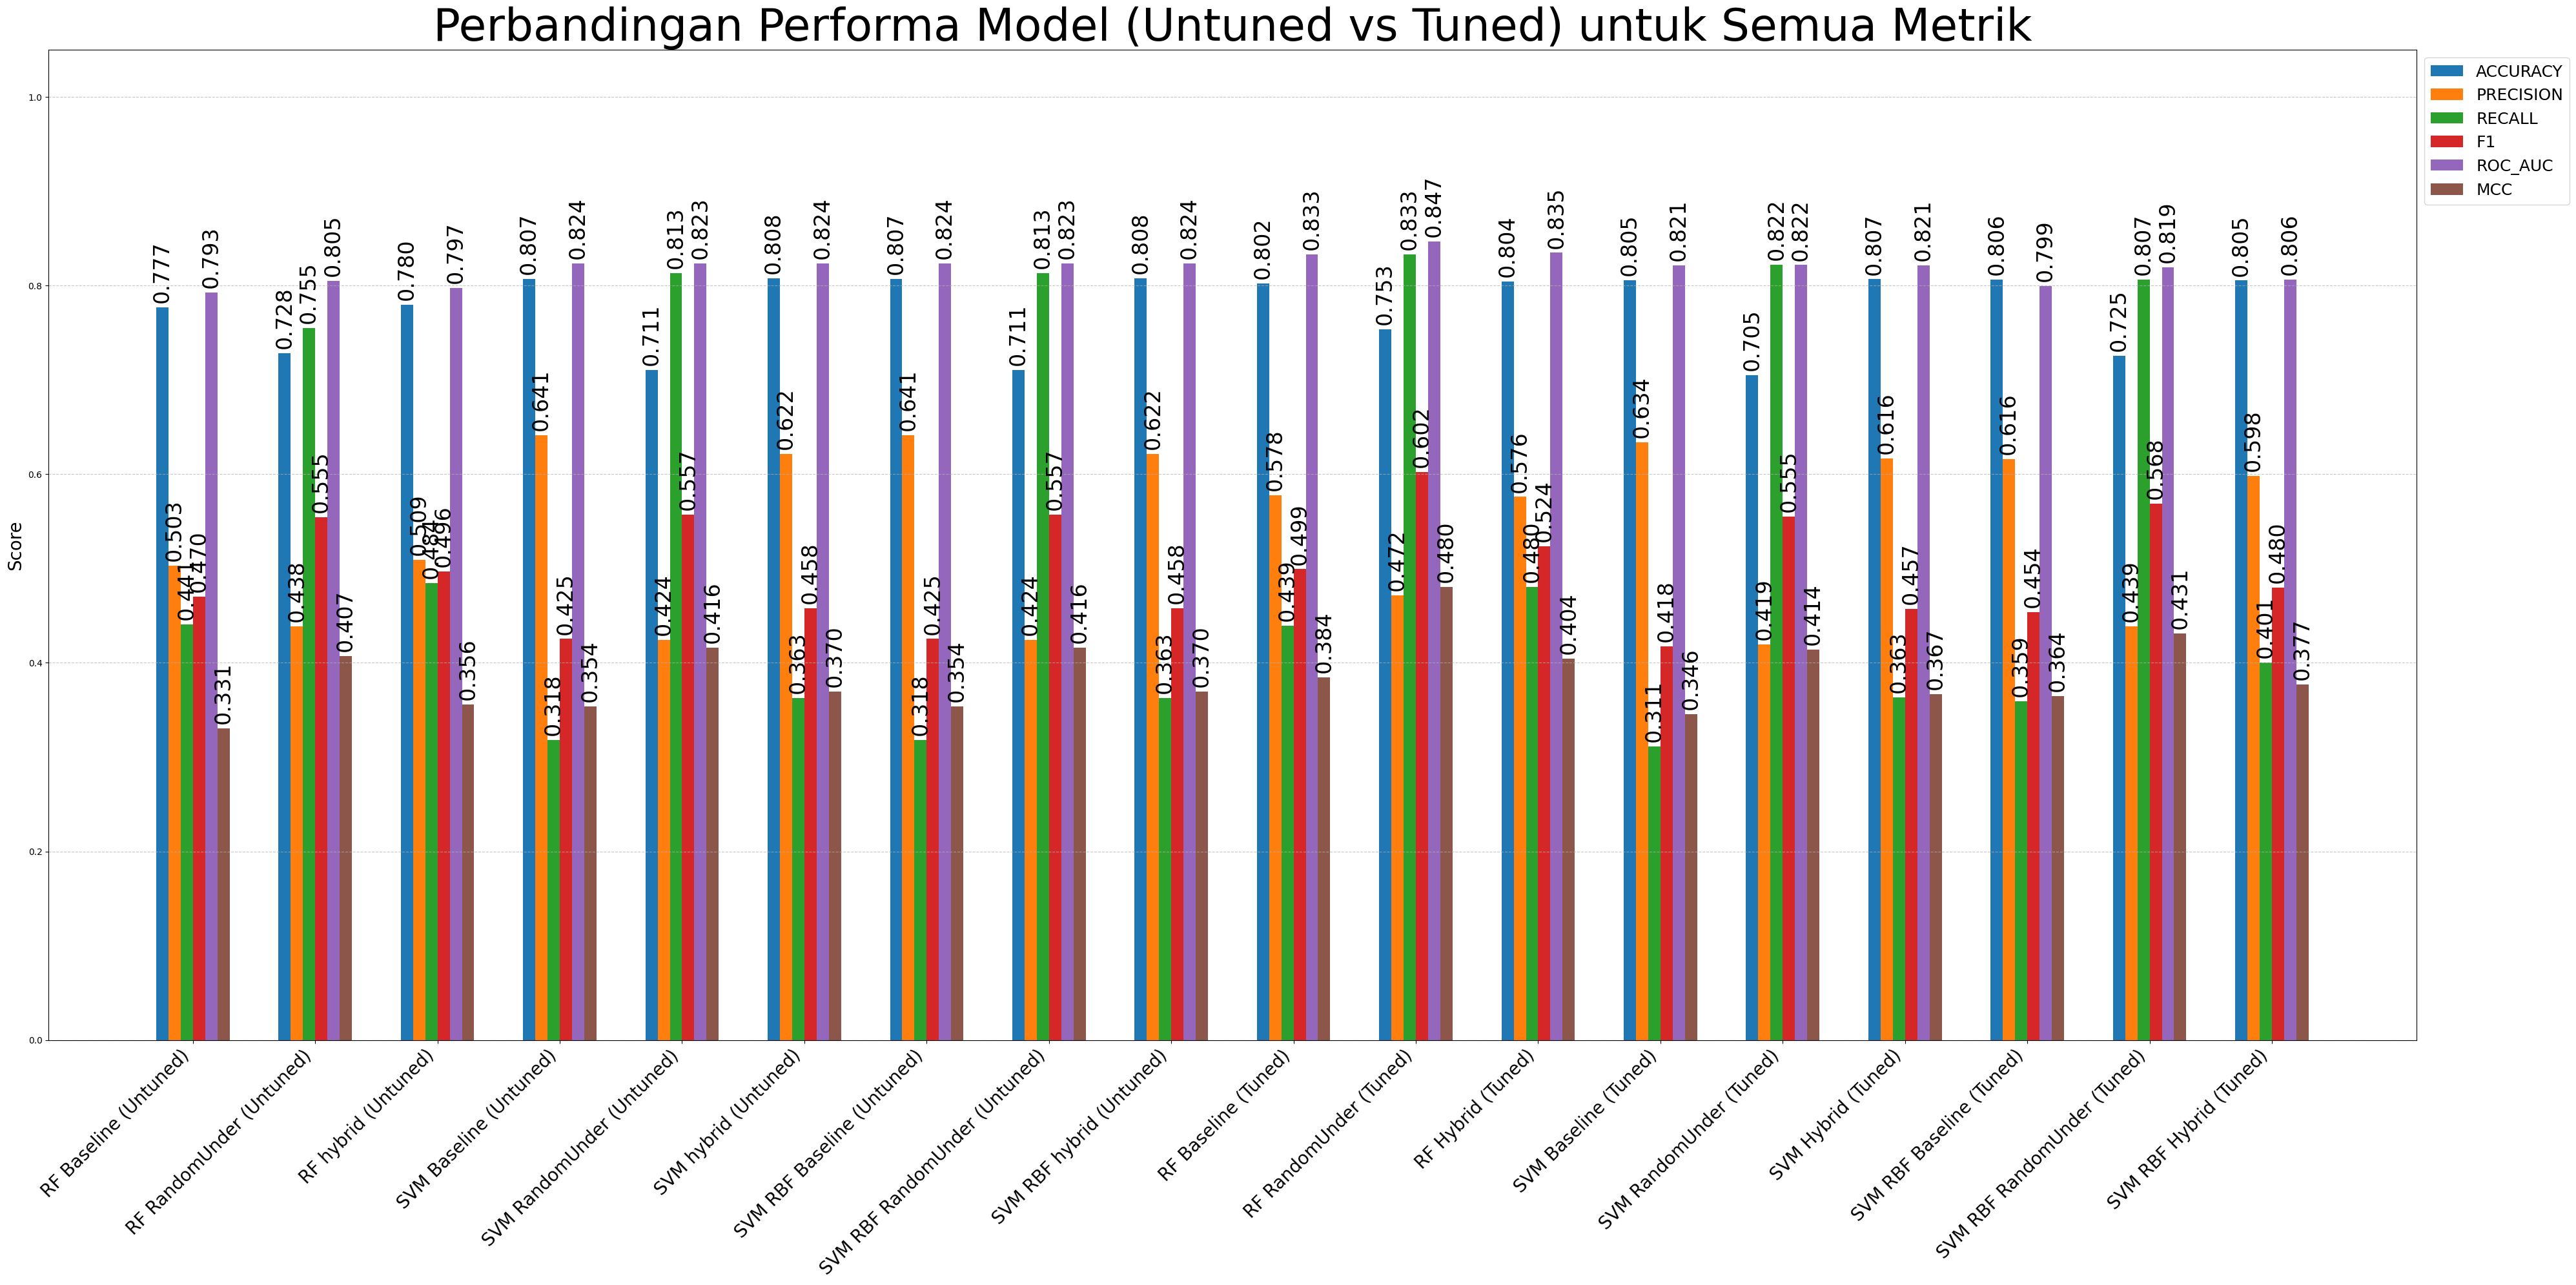

In [111]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc']
labels = combined_full_results['label'].values
x_base = np.arange(len(labels))

x = x_base * 1.5
width = 0.15

fig, ax = plt.subplots(figsize=(40, 20))

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(
        x + i*width,
        combined_full_results[metric],
        width,
        label=metric.upper()
    )

    # Tambahkan angka di atas bar
    ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=24, rotation=90)

ax.set_xticks(x + width * (len(metrics_to_plot) - 1 ) / 2)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('Score', fontsize=20)
ax.set_title('Perbandingan Performa Model (Untuned vs Tuned) untuk Semua Metrik', fontsize=50)
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=18)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0,1.05)
plt.tight_layout()
plt.show()

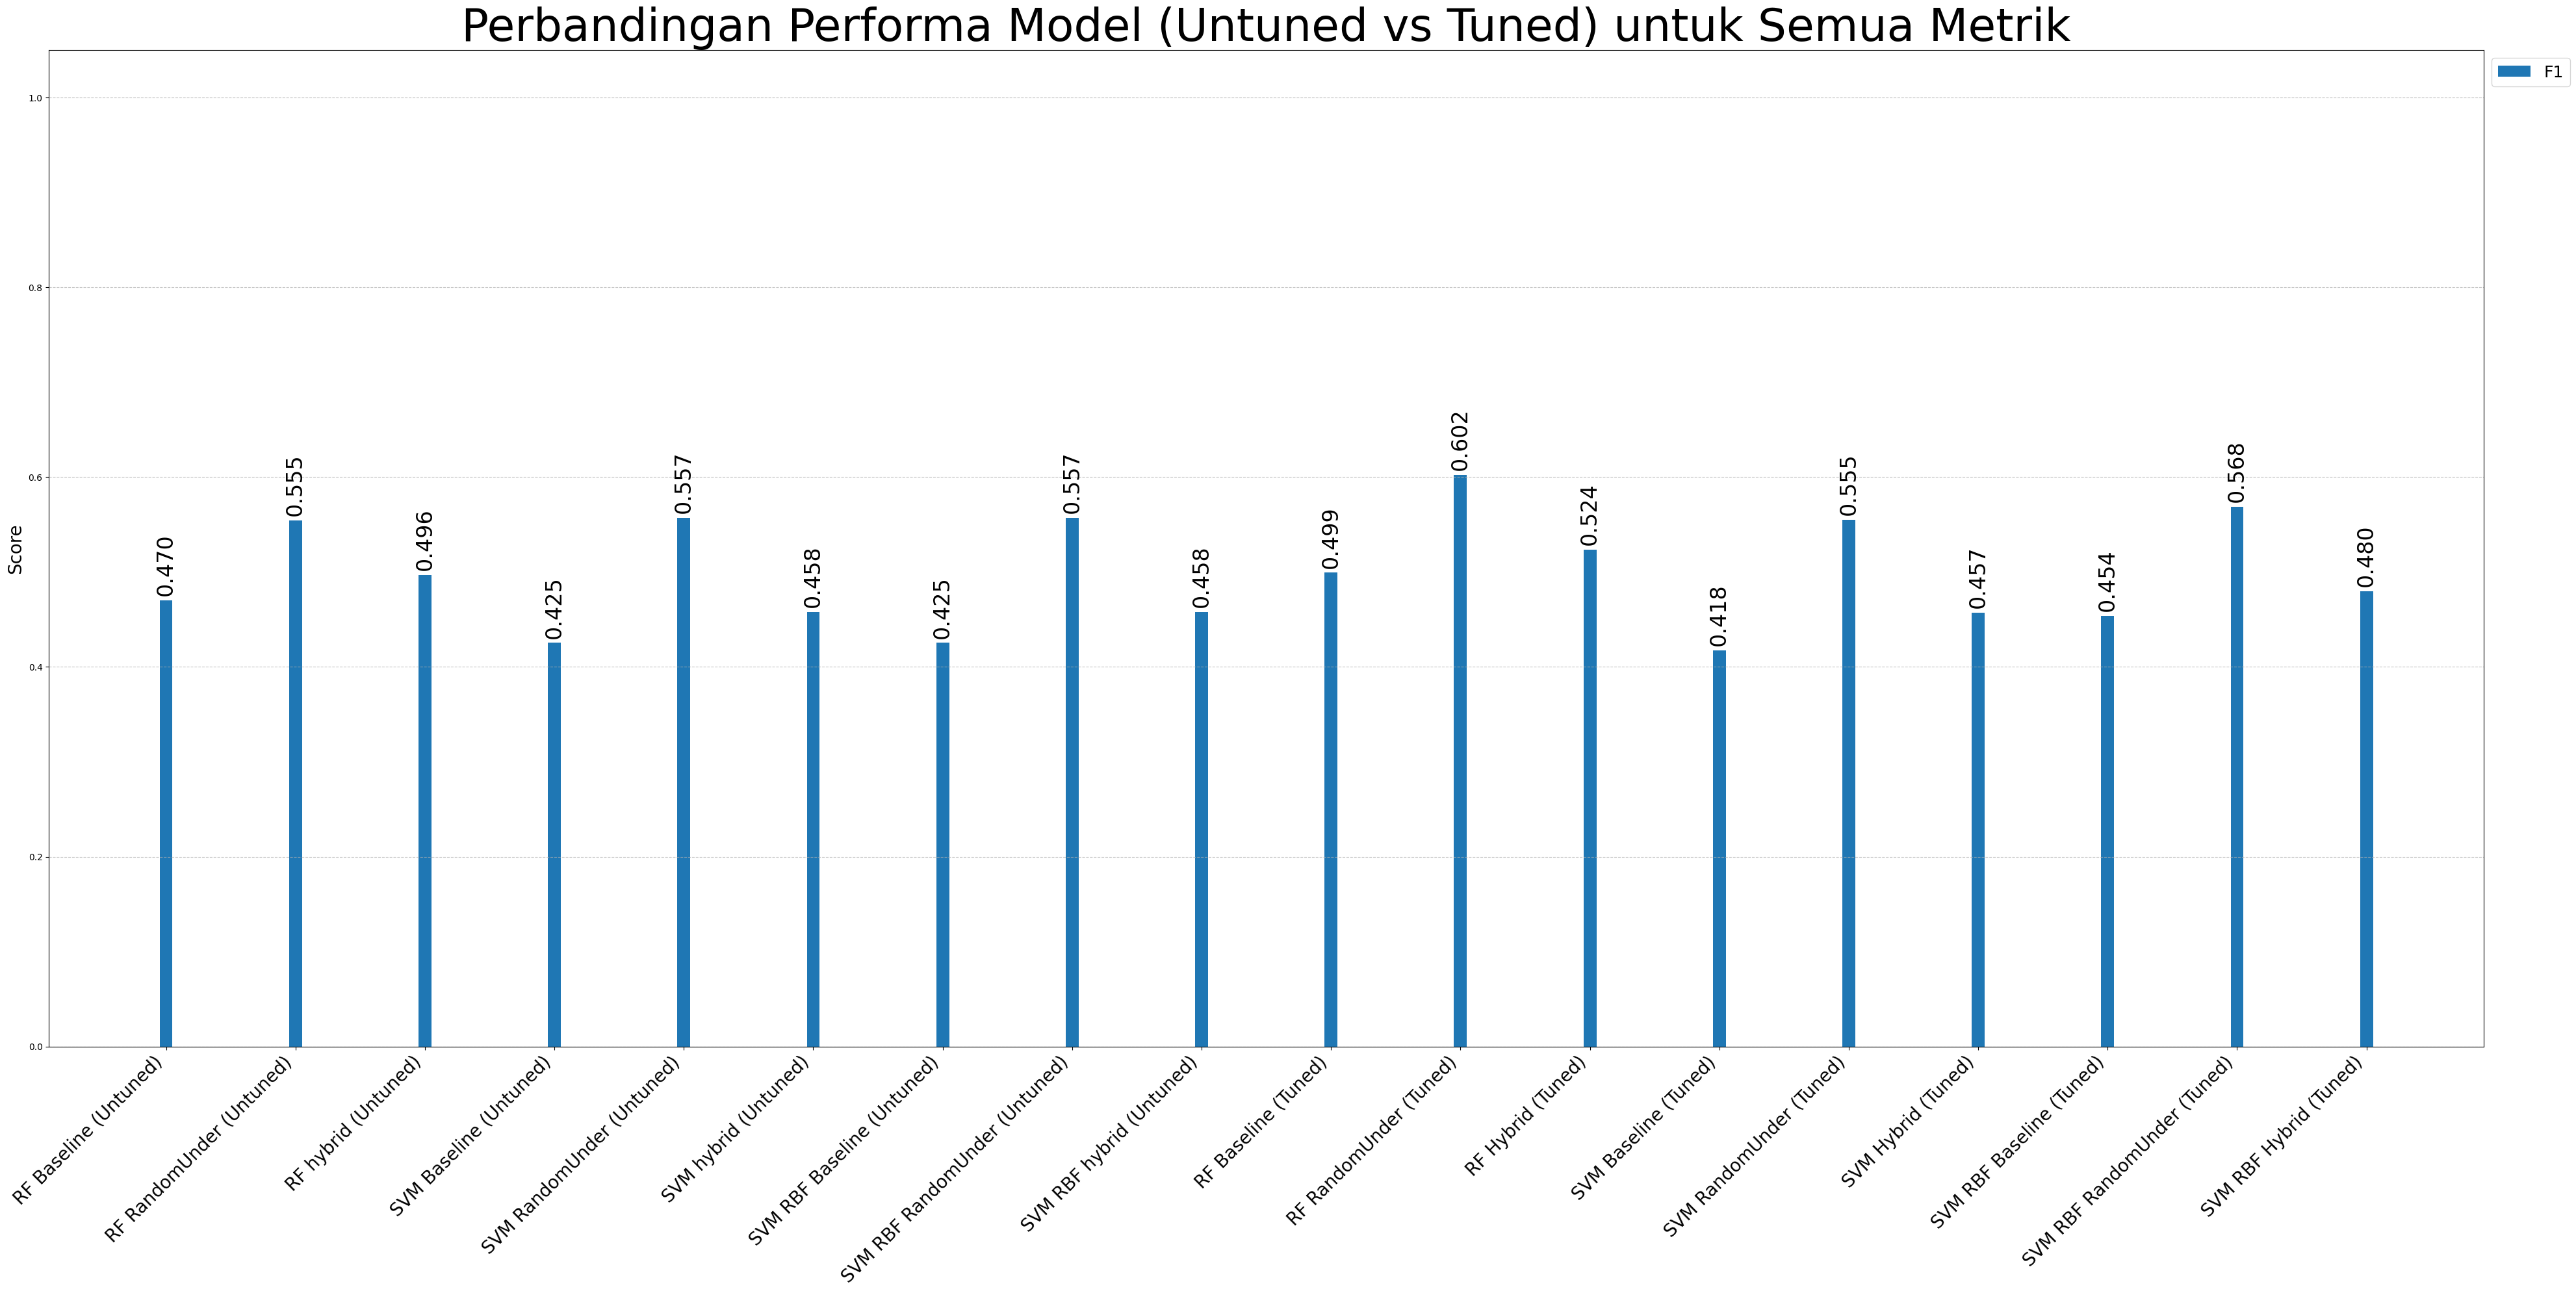

In [112]:
metrics_to_plot = ['f1']
labels = combined_full_results['label'].values
x_base = np.arange(len(labels))

x = x_base * 1.5
width = 0.15

fig, ax = plt.subplots(figsize=(40, 20))

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(
        x + i*width,
        combined_full_results[metric],
        width,
        label=metric.upper()
    )

    # Tambahkan angka di atas bar
    ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=24, rotation=90)

ax.set_xticks(x + width * (len(metrics_to_plot) - 1 ) / 2)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('Score', fontsize=20)
ax.set_title('Perbandingan Performa Model (Untuned vs Tuned) untuk Semua Metrik', fontsize=50)
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=18)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0,1.05)
plt.tight_layout()
plt.show()

In [113]:
def plot_confusion_matrix(pipe, X_test, y_test, title):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

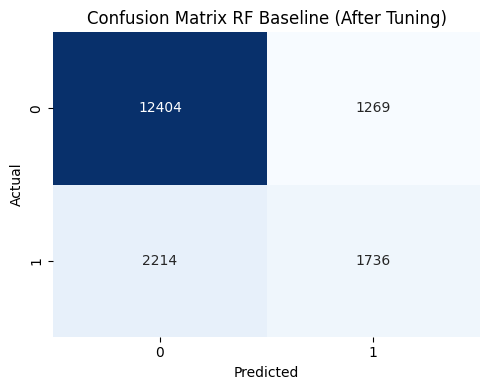

In [114]:
plot_confusion_matrix(
    best_rf,
    X_test,
    y_test,
    "Confusion Matrix RF Baseline (After Tuning)"
)

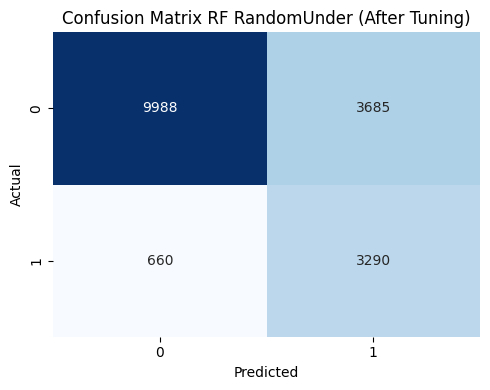

In [115]:
plot_confusion_matrix(
    best_rf_random,
    X_test,
    y_test,
    "Confusion Matrix RF RandomUnder (After Tuning)"
)

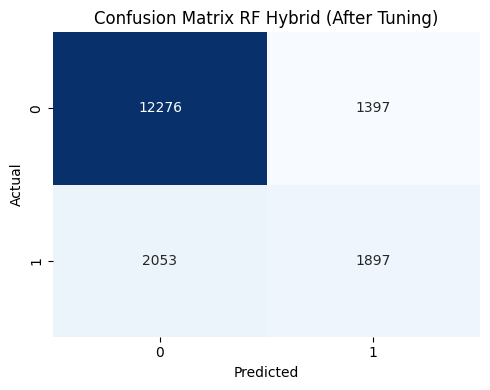

In [116]:
plot_confusion_matrix(
    best_rf_hybrid,
    X_test,
    y_test,
    "Confusion Matrix RF Hybrid (After Tuning)"
)

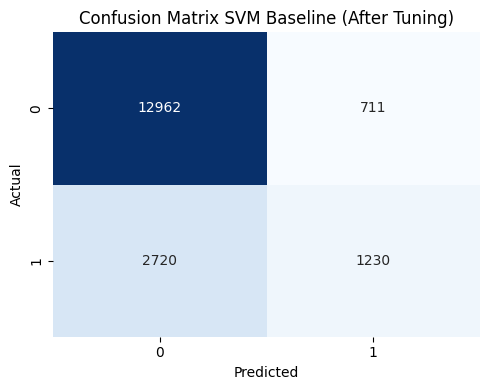

In [117]:
plot_confusion_matrix(
    best_svm,
    X_test,
    y_test,
    "Confusion Matrix SVM Baseline (After Tuning)"
)

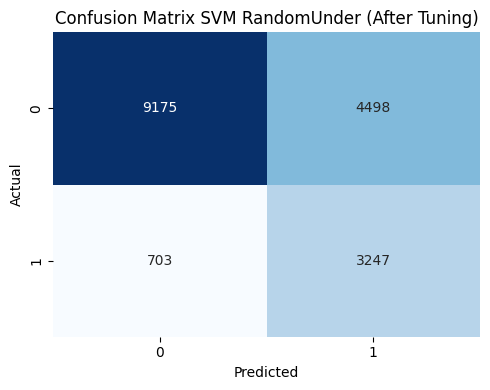

In [118]:
plot_confusion_matrix(
    best_svm_random,
    X_test,
    y_test,
    "Confusion Matrix SVM RandomUnder (After Tuning)"
)

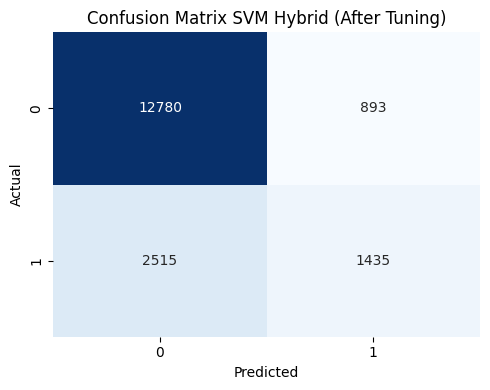

In [119]:
plot_confusion_matrix(
    best_svm_hybrid,
    X_test,
    y_test,
    "Confusion Matrix SVM Hybrid (After Tuning)"
)

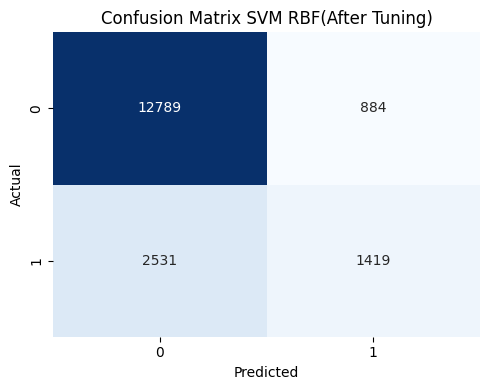

In [120]:
plot_confusion_matrix(
    best_svm_rbf,
    X_test,
    y_test,
    "Confusion Matrix SVM RBF(After Tuning)"
)

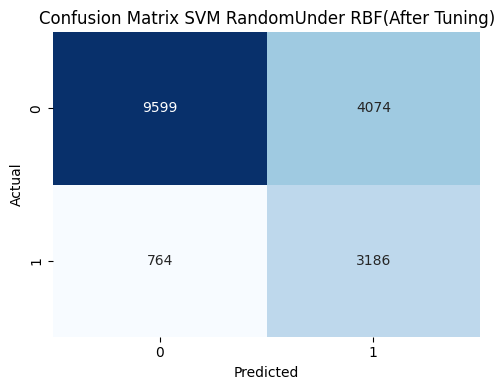

In [121]:
plot_confusion_matrix(
    best_svm__rbf_random,
    X_test,
    y_test,
    "Confusion Matrix SVM RandomUnder RBF(After Tuning)"
)

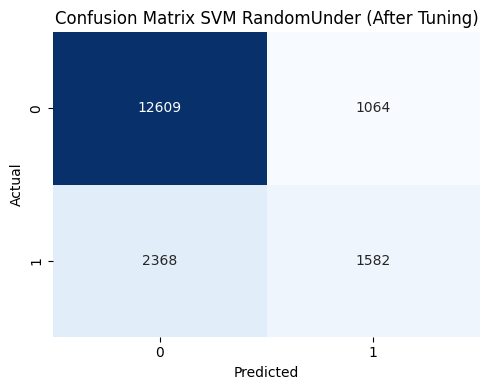

In [122]:
plot_confusion_matrix(
    best_svm_rbf_hybrid,
    X_test,
    y_test,
    "Confusion Matrix SVM RandomUnder (After Tuning)"
)

In [123]:
def plot_roc(pipe, X_train, X_test, y_train, y_test, label):
    pipe.fit(X_train, y_train)

    if hasattr(pipe.named_steps['classifier'], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    else:
        y_score = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

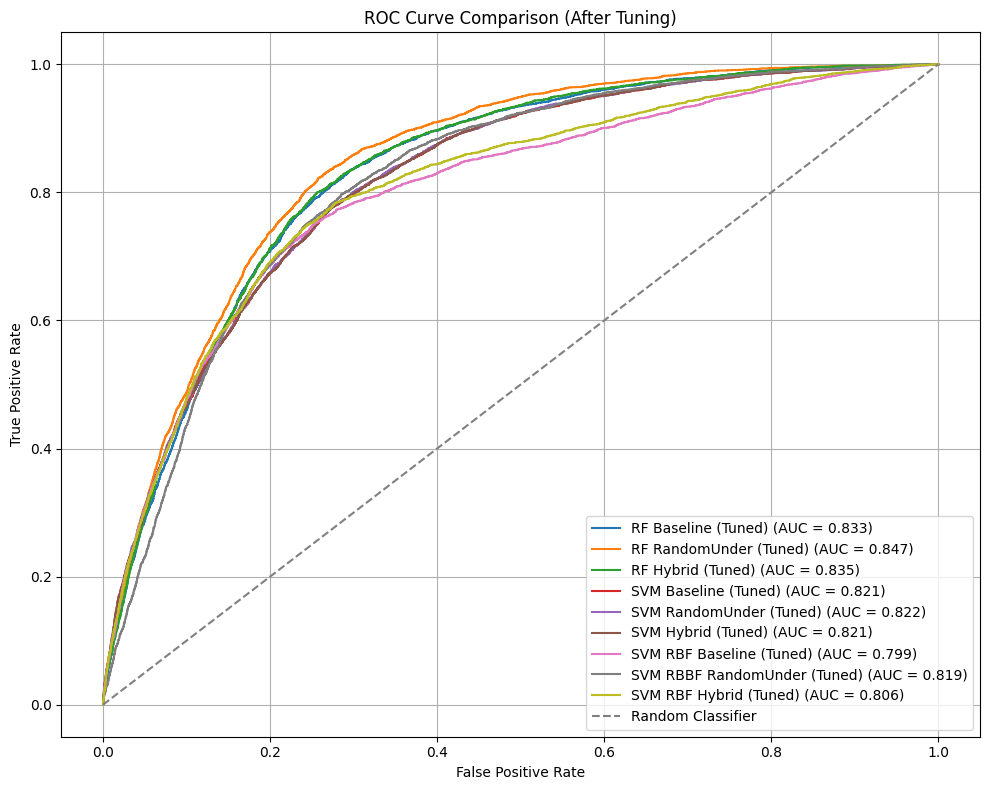

In [124]:
plt.figure(figsize=(10, 8))

models_to_plot = [
    (best_rf, "RF Baseline (Tuned)"),
    (best_rf_random, "RF RandomUnder (Tuned)"),
    (best_rf_hybrid, "RF Hybrid (Tuned)"),
    (best_svm, "SVM Baseline (Tuned)"),
    (best_svm_random, "SVM RandomUnder (Tuned)"),
    (best_svm_hybrid, "SVM Hybrid (Tuned)"),
    (best_svm_rbf, "SVM RBF Baseline (Tuned)"),
    (best_svm__rbf_random, "SVM RBBF RandomUnder (Tuned)"),
    (best_svm_rbf_hybrid, "SVM RBF Hybrid (Tuned)"),
]

for pipe, label in models_to_plot:
    plot_roc(pipe, X_train, X_test, y_train, y_test, label)

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (After Tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mcnemar (Fokus ke perbedaann salah setiap model secara statistik)

In [125]:
best_rf_model = best_rf_random
best_svm_model = best_svm__rbf_random

In [126]:
y_pred_rf = best_rf_model.predict(X_test)
y_pred_svm = best_svm_model.predict(X_test)

In [127]:
# n01: RF salah, SVM benar
n01 = np.sum((y_pred_rf != y_test) & (y_pred_svm == y_test))

# n10: RF benar, SVM salah
n10 = np.sum((y_pred_rf == y_test) & (y_pred_svm != y_test))

print(f"n01 (RF salah, SVM benar): {n01}")
print(f"n10 (RF benar, SVM salah): {n10}")


n01 (RF salah, SVM benar): 652
n10 (RF benar, SVM salah): 1145


In [128]:
table = [[0, n01],
         [n10, 0]]

result = mcnemar(table, exact=False, correction=True)

print("McNemar statistic:", result.statistic)
print("p-value:", result.pvalue)


McNemar statistic: 134.70450751252088
p-value: 3.831515152481204e-31


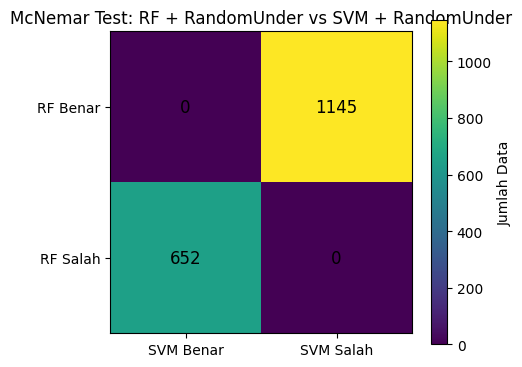

In [129]:
n01 = 652  # RF salah, SVM benar
n10 = 1145   # RF benar, SVM salah

mcnemar_matrix = np.array([
    [0,   n10],
    [n01, 0]
])

plt.figure(figsize=(5,4))
plt.imshow(mcnemar_matrix)
plt.colorbar(label='Jumlah Data')

plt.xticks([0,1], ['SVM Benar', 'SVM Salah'])
plt.yticks([0,1], ['RF Benar', 'RF Salah'])

# anotasi angka
for i in range(2):
    for j in range(2):
        plt.text(j, i, mcnemar_matrix[i, j],
                 ha='center', va='center', fontsize=12)

plt.title('McNemar Test: RF + RandomUnder vs SVM + RandomUnder')
plt.tight_layout()
plt.show()

Hasil uji McNemar menunjukkan adanya perbedaan performa yang signifikan antara model Random Forest dengan RandomUnderSampling dan SVM Kernel RBF dengan RandomUnderSampling. Hal ini ditunjukkan oleh jumlah prediksi benar unik Random Forest yang lebih tinggi dibandingkan SVM, Random Forest terbukti memiliki performa yang secara statistik lebih baik.

Walaupun SVM RBF memiliki F1-score tertinggi, Random Forest dipilih sebagai model akhir karena performanya lebih stabil dan memiliki kemampuan generalisasi yang baik.

MODEL FINAL = RF + RandomUndersampling

In [130]:
pipeline_random_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('all', 'passthrough',
                                                  ['usia', 'pendidikan',
                                                   'pekerjaan', 'jenis_kelamin',
                                                   'kab_kota', 'tipe_daerah',
                                                   'status_kawin'])])),
                ('undersampler', RandomUnderSampler(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [131]:
feature_names = (
    pipeline_random_rf
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [132]:
rf_model = pipeline_random_rf.named_steps['classifier']
importances = rf_model.feature_importances_ #tingkat pengaruh fitur terhadap prediksi model

In [133]:
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

fi_df.head(10)

,feature,importance
0,all__usia,0.309152
4,all__kab_kota,0.237233
3,all__jenis_kelamin,0.210413
1,all__pendidikan,0.131573
2,all__pekerjaan,0.057944
6,all__status_kawin,0.030859
5,all__tipe_daerah,0.022826


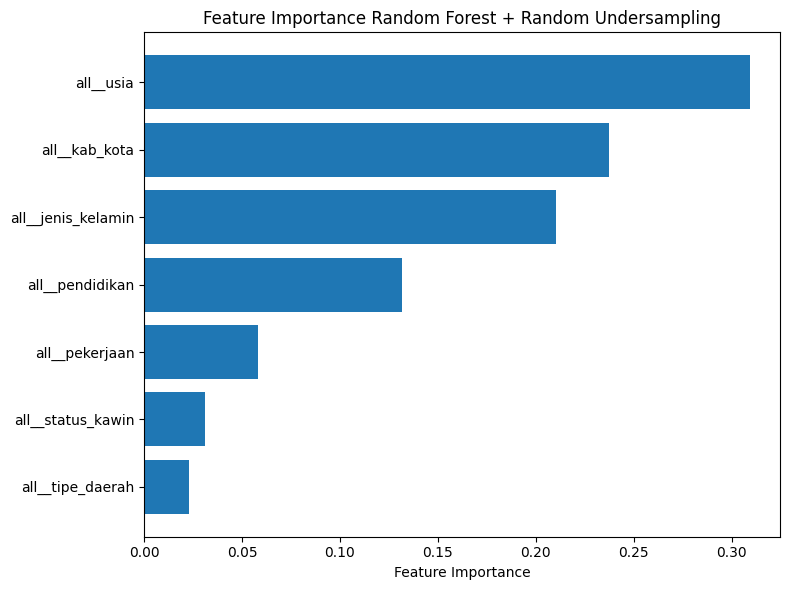

In [134]:
plt.figure(figsize=(8,6))

plt.barh(
    fi_df['feature'][:15][::-1],
    fi_df['importance'][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Feature Importance Random Forest + Random Undersampling")
plt.tight_layout()
plt.show()

Variabel usia memiliki importance tertinggi karena pernikahan dini secara langsung berkaitan dengan batas usia pernikahan.

Kabupaten/kota memiliki pengaruh besar karena kondisi sosial ekonomi dan budaya tiap wilayah berbeda-beda.

Jenis kelamin. pernikahan dini lebih banyak terjadi pada perempuan.

Pendidikan berpengaruh karena tingkat pendidikan yang rendah sering dikaitkan dengan meningkatnya risiko pernikahan dini.


In [135]:
from sklearn.inspection import permutation_importance
#mengukur seberapa penting fitur terhadap performa model dengan cara mengacak niali fitur
perm = permutation_importance(
    pipeline_random_rf,
    X_test,
    y_test,
    n_repeats=10, #pengecekan fitur dilakukan 10 kali agar stabil dan tidak dipengaruhi randomisasi tunggal
    random_state=42,
    scoring='f1' #klasifikasi data imbalance
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm.importances_mean
}).sort_values(by='importance', ascending=False)

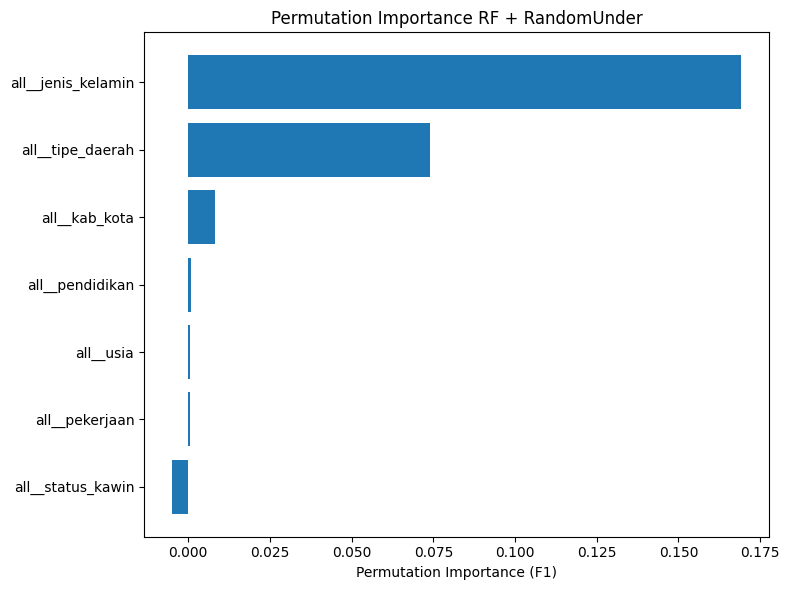

In [136]:
plt.figure(figsize=(8,6))

plt.barh(
    perm_df['feature'][:15][::-1],
    perm_df['importance'][:15][::-1]
)

plt.xlabel("Permutation Importance (F1)")
plt.title("Permutation Importance RF + RandomUnder")
plt.tight_layout()
plt.show()

Faktor demografis seperti jenis kelamin dan tipe daerah memberikan pengaruh paling besar terhadap kemampuan model dalam mendeteksi pernikahan dini.

Permutation importance lebih interpretatif karena mengukur penurunan performa model secara langsung ketika fitur diacak.

Feature importance Random Forest menunjukkan bahwa kabupaten/kota sering digunakan dalam pembentukan decision tree. Namun berdasarkan permutation importance, jenis kelamin dan tipe daerah memberikan pengaruh terbesar terhadap performa model karena ketika fitur tersebut diacak, nilai F1-score mengalami penurunan paling signifikan.

In [148]:
import numpy as np

df_temp = df.copy()
df_temp['jenis_kelamin_reconstructed'] = np.select(
    [df_temp['jenis_kelamin_laki-laki'] == 1, df_temp['jenis_kelamin_perempuan'] == 1],
    ['laki-laki', 'perempuan'],
    default=None
)

pd.crosstab(
    df_temp['jenis_kelamin_reconstructed'],
    df_temp['pernikahan_dini'],
    normalize='index'
) * 100

pernikahan_dini,0.0,1.0
jenis_kelamin_reconstructed,,
laki-laki,77.714617,22.285383
perempuan,77.289856,22.710144


In [149]:
df_temp = df.copy()
df_temp['tipe_daerah_reconstructed'] = np.select(
    [df_temp['tipe_daerah_perkotaan'] == 1, df_temp['tipe_daerah_pedesaan'] == 1],
    ['perkotaan', 'pedesaan'],
    default=None
)

pd.crosstab(
    df_temp['tipe_daerah_reconstructed'],
    df_temp['pernikahan_dini'],
    normalize='index'
) * 100

pernikahan_dini,0.0,1.0
tipe_daerah_reconstructed,,
pedesaan,77.756844,22.243156
perkotaan,77.232026,22.767974


In [167]:
df_temp_crosstab = df.copy()

all_kab_ohe_cols_in_df = [col for col in df_temp_crosstab.columns if col.startswith('kab_kota_')]

unique_kab_ohe_cols = []
processed_names = set()

for col_name in all_kab_ohe_cols_in_df:
    if col_name not in processed_names:
        unique_kab_ohe_cols.append(col_name)
        processed_names.add(col_name)

conditions = []
choices = []

for col_name in unique_kab_ohe_cols:
    col_data = df_temp_crosstab[col_name]

    if isinstance(col_data, pd.DataFrame):
        conditions.append(col_data.iloc[:, 0] == 1)
    else:
        conditions.append(col_data == 1)

    if col_name == 'kab_kota_nan':
        choices.append(None)
    else:
        choices.append(col_name.replace('kab_kota_', ''))

df_temp_crosstab['kab_kota_reconstructed'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

df_temp_crosstab = df_temp_crosstab[
    df_temp_crosstab['kab_kota_reconstructed'] != 'Unknown'
]

ct_kab = pd.crosstab(
    df_temp_crosstab['kab_kota_reconstructed'],
    df_temp_crosstab['pernikahan_dini'],
    normalize='index'
) * 100

ct_kab = ct_kab.sort_values(by=1.0, ascending=False)

ct_kab.head(10)

pernikahan_dini,0.0,1.0
kab_kota_reconstructed,,
SUKOHARJO,63.842365,36.157635
PEMALANG,65.787432,34.212568
WONOSOBO,67.080745,32.919255
KENDAL,67.462423,32.537577
PURWOREJO,69.336143,30.663857
KAB_PEKALONGAN,70.691091,29.308909
CILACAP,73.187311,26.812689
BATANG,73.217550,26.782450
KAB_TEGAL,73.580034,26.419966


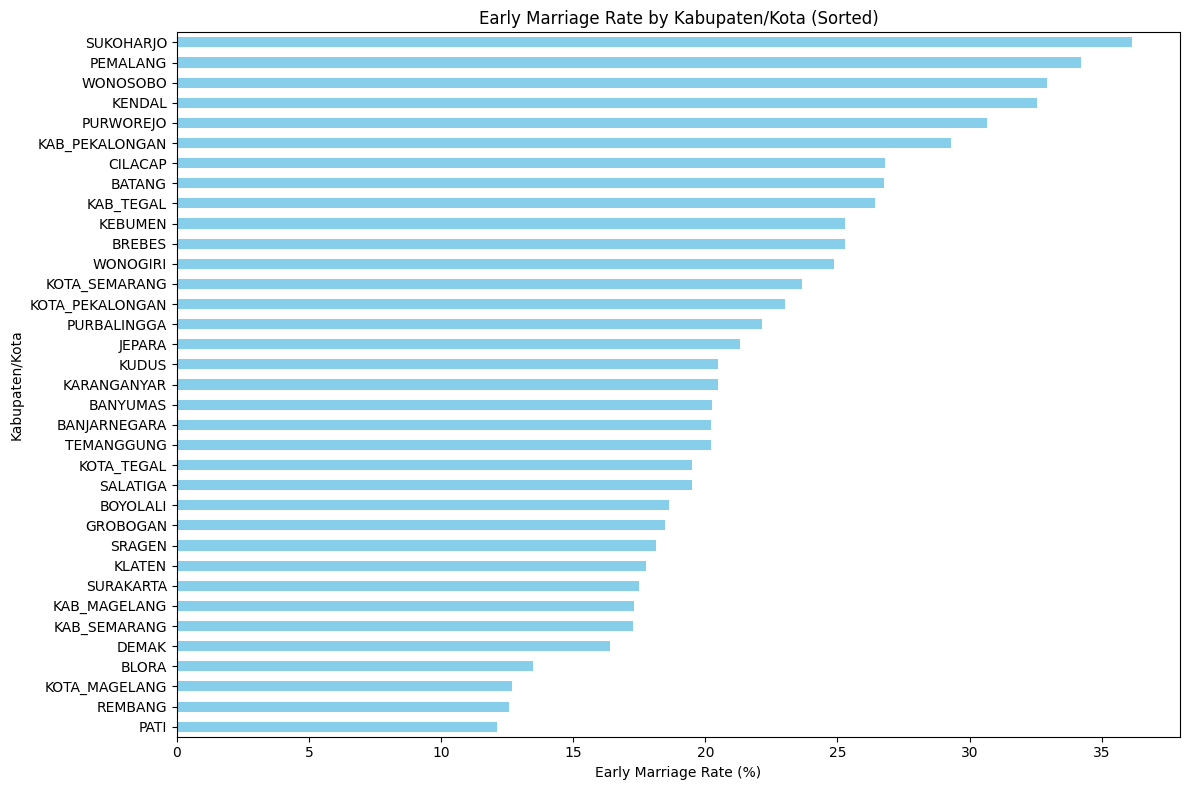

In [168]:
plt.figure(figsize=(12, 8))
ct_kab[1.0].plot(kind='barh', color='skyblue')
plt.title('Early Marriage Rate by Kabupaten/Kota (Sorted)')
plt.xlabel('Early Marriage Rate (%)')
plt.ylabel('Kabupaten/Kota')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()